# KG-Guided Activation Steering — Extended Ablation & Robustness Notebook
## IEEE TKDE Special Issue: Data and Knowledge Empowered Generative AI (DK-GenAI)

**Paper:** Knowledge-Graph-Gated Defactualization for Leakage-Free, Style-Controllable Generation  
**Purpose:** Extended ablations, negative-result transparency, and reviewer-ready supplementary analyses  
**Requirement:** Place `metrics_all_models_combined.csv` (from Evaluation.zip) alongside this notebook, or update `CSV_PATH` below.

### What this notebook adds beyond DSR_Supplementary_Analysis.ipynb

| Section | New contribution |
|---------|-----------------|
| A. Steering-Mode Decoupling | Partial η² ANOVA — how much variance is explained by *model* vs *scenario* vs *urgency* |
| B. Entity-Type Sparsity Analysis | Zero-inflation model; flag structurally uncapturable entity types |
| C. Ordinal Urgency–Coverage Regression | Jonckheere-Terpstra trend test: does urgency level modulate coverage? |
| D. Tone × Scenario Interaction | 2-way mixed ANOVA on entity coverage; interaction plots |
| E. Intra-Model Consistency (ICC) | Intraclass correlation — are results repeatable within a model across scenarios? |
| F. Cross-Generation Contrast | Llama-2 vs Llama-3 family t-tests on all key metrics; DK-GenAI architecture angle |
| G. KG Graph Efficiency Frontier | Pareto front: nodes/edges vs coverage; identify over/under-specified KGs |
| H. Style Calibration Error (SCE) | Novel metric — gap between intended and achieved formality/empathy |
| I. Negative Result Quantification | Bounded effect sizes with confidence intervals; honest null results |
| J. Reviewer-Ready LaTeX Tables | Auto-generated .tex tables for paper inclusion |


## 0. Setup & Data Loading

In [1]:

import subprocess, sys
for pkg in ["scipy", "statsmodels", "seaborn", "matplotlib", "pandas", "numpy", "pingouin"]:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", pkg], check=False)
print("Dependencies installed ✓")


Dependencies installed ✓


In [2]:

import warnings; warnings.filterwarnings("ignore")
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
from scipy.stats import (ttest_rel, ttest_ind, wilcoxon, pearsonr, spearmanr,
                          f_oneway, kruskal, mannwhitneyu)
from statsmodels.stats.multitest import multipletests
from statsmodels.stats.anova import AnovaRM
import itertools, os
from pathlib import Path

# ── Try pingouin for ICC & partial eta² ──────────────────────────────────────
try:
    import pingouin as pg
    HAS_PINGOUIN = True
except ImportError:
    HAS_PINGOUIN = False
    print("pingouin not available — ICC will use manual fallback")

sns.set_theme(style="whitegrid", font_scale=1.1)
plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "figure.dpi": 150,
})

PALETTE = {
    "L2-7B-Base":  "#1f77b4",
    "L2-7B-Chat":  "#ff7f0e",
    "L2-13B-Chat": "#2ca02c",
    "L3.2-1B":     "#d62728",
    "L3.2-3B":     "#9467bd",
    "L3.1-8B":     "#8c564b",
}
PALETTE_GEN = {"Llama-2": "#1f77b4", "Llama-3": "#d62728"}
MODEL_ORDER = ["L2-7B-Base","L2-7B-Chat","L2-13B-Chat","L3.2-1B","L3.2-3B","L3.1-8B"]
print("Setup complete ✓")


Setup complete ✓


In [4]:

# ── Update CSV_PATH to match your local setup ─────────────────────────────────
CSV_PATH = "D:\ACE API [Gold]\KG-Guided-Activation-Steering-for-Preventing-Semantic-Leakage-in-Agentic-Conversational-AI-main\Evaluation\Evaluation\metrics_all_models_combined.csv"   # from Evaluation.zip → Evaluation/

df = pd.read_csv(CSV_PATH)

# Derived columns used throughout
df["avg_entity_cov"]  = (df["emp_entity_cov"] + df["frm_entity_cov"]) / 2
df["flesch_delta"]    = df["emp_flesch_ease"] - df["frm_flesch_ease"]
df["fog_delta"]       = df["frm_fog"] - df["emp_fog"]
df["style_gap"]       = df["emp_empathy_score"] - df["frm_formality_score"]  # intended gap
df["achieved_gap"]    = df["emp_empathy_score"] - df["frm_empathy_score"]    # achieved
df["kg_edge_per_node"]= df["kg_edges"] / (df["kg_nodes"] + 1e-9)

print(f"Loaded: {len(df)} rows × {df.shape[1]} cols")
print("Models  :", df['model_short'].unique().tolist())
print("Scenarios:", df['scenario'].unique().tolist())
print("Cases/model:", df.groupby('model_short').size().to_dict())
df.head(2)


Loaded: 600 rows × 63 cols
Models  : ['L2-7B-Chat', 'L2-7B-Base', 'L2-13B-Chat', 'L3.1-8B', 'L3.2-1B', 'L3.2-3B']
Scenarios: ['battery_issue', 'wrong_item', 'billing_error', 'delivery_delay']
Cases/model: {'L2-13B-Chat': 100, 'L2-7B-Base': 100, 'L2-7B-Chat': 100, 'L3.1-8B': 100, 'L3.2-1B': 100, 'L3.2-3B': 100}


,case_index,scenario,sentiment,urgency,emp_steering,frm_steering,emp_token_len,frm_token_len,emp_sent_len,frm_sent_len,...,model_short,generation,size_B,model_type,avg_entity_cov,flesch_delta,fog_delta,style_gap,achieved_gap,kg_edge_per_node
0,1,battery_issue,frustrated,high,kg_activation,kg_activation,53,57,3,3,...,L2-7B-Chat,Llama-2,7,chat,0.0,31.225571,10.159825,-0.034483,0.0,0.666667
1,2,battery_issue,angry,high,kg_activation,kg_activation,37,43,2,2,...,L2-7B-Chat,Llama-2,7,chat,0.0,9.706882,0.363763,-0.068966,0.0,0.428571


---
## A. Variance Decomposition — How Much Variance Does Each Factor Explain?

**Research question for DK-GenAI:** Is entity-coverage variance driven by the *host model*, 
the *input scenario*, the *customer sentiment*, or the *urgency*?  
We use a one-way ANOVA per factor and compute **partial η²** (effect size) for each.  
This directly answers: *"Is your KG layer effect model-specific or input-driven?"*


In [5]:

from scipy.stats import f_oneway

factors = {
    "model_short": "Host Model",
    "scenario":    "Scenario Type",
    "sentiment":   "Customer Sentiment",
    "urgency":     "Urgency Level",
    "generation":  "LLM Generation (Llama-2 vs 3)",
    "model_type":  "Model Type (base/chat/instruct)",
}
target_cols = {
    "avg_entity_cov":  "Avg Entity Coverage",
    "style_disc_score":"Style Discrimination Score",
    "flesch_delta":    "Readability Δ (Emp−Frm)",
    "kg_density":      "KG Graph Density",
}

eta2_rows = []
for factor, factor_label in factors.items():
    for col, col_label in target_cols.items():
        groups = [df[df[factor]==v][col].dropna().values for v in df[factor].unique()]
        groups = [g for g in groups if len(g) > 1]
        f_stat, p_val = f_oneway(*groups)
        # Partial η²  = SS_between / (SS_between + SS_within)
        grand_mean = df[col].dropna().mean()
        ss_between = sum(len(g) * (g.mean() - grand_mean)**2 for g in groups)
        ss_within  = sum(((g - g.mean())**2).sum() for g in groups)
        eta2 = ss_between / (ss_between + ss_within + 1e-12)
        eta2_rows.append({
            "Factor": factor_label,
            "Metric": col_label,
            "F-stat": round(f_stat, 3),
            "p-value": round(p_val, 6),
            "Partial η²": round(eta2, 4),
            "Interpretation": ("large" if eta2 >= 0.14 else
                               "medium" if eta2 >= 0.06 else
                               "small"  if eta2 >= 0.01 else "negligible"),
            "Sig": "***" if p_val < 0.001 else ("**" if p_val < 0.01 else ("*" if p_val < 0.05 else "n.s.")),
        })

eta2_df = pd.DataFrame(eta2_rows)
print("=== Partial η² Variance Decomposition ===")
print(eta2_df.to_string(index=False))
eta2_df.to_csv("tableA1_variance_decomposition.csv", index=False)
print("\nSaved tableA1_variance_decomposition.csv")


=== Partial η² Variance Decomposition ===
                         Factor                     Metric  F-stat  p-value  Partial η² Interpretation  Sig
                     Host Model        Avg Entity Coverage   4.973 0.000180      0.0402          small  ***
                     Host Model Style Discrimination Score  11.549 0.000000      0.0886         medium  ***
                     Host Model    Readability Δ (Emp−Frm)  35.606 0.000000      0.2306          large  ***
                     Host Model           KG Graph Density   0.125 0.986839      0.0010     negligible n.s.
                  Scenario Type        Avg Entity Coverage  11.183 0.000000      0.0533          small  ***
                  Scenario Type Style Discrimination Score   0.404 0.749877      0.0020     negligible n.s.
                  Scenario Type    Readability Δ (Emp−Frm)   1.931 0.123310      0.0096     negligible n.s.
                  Scenario Type           KG Graph Density  11.248 0.000000      0.0536       

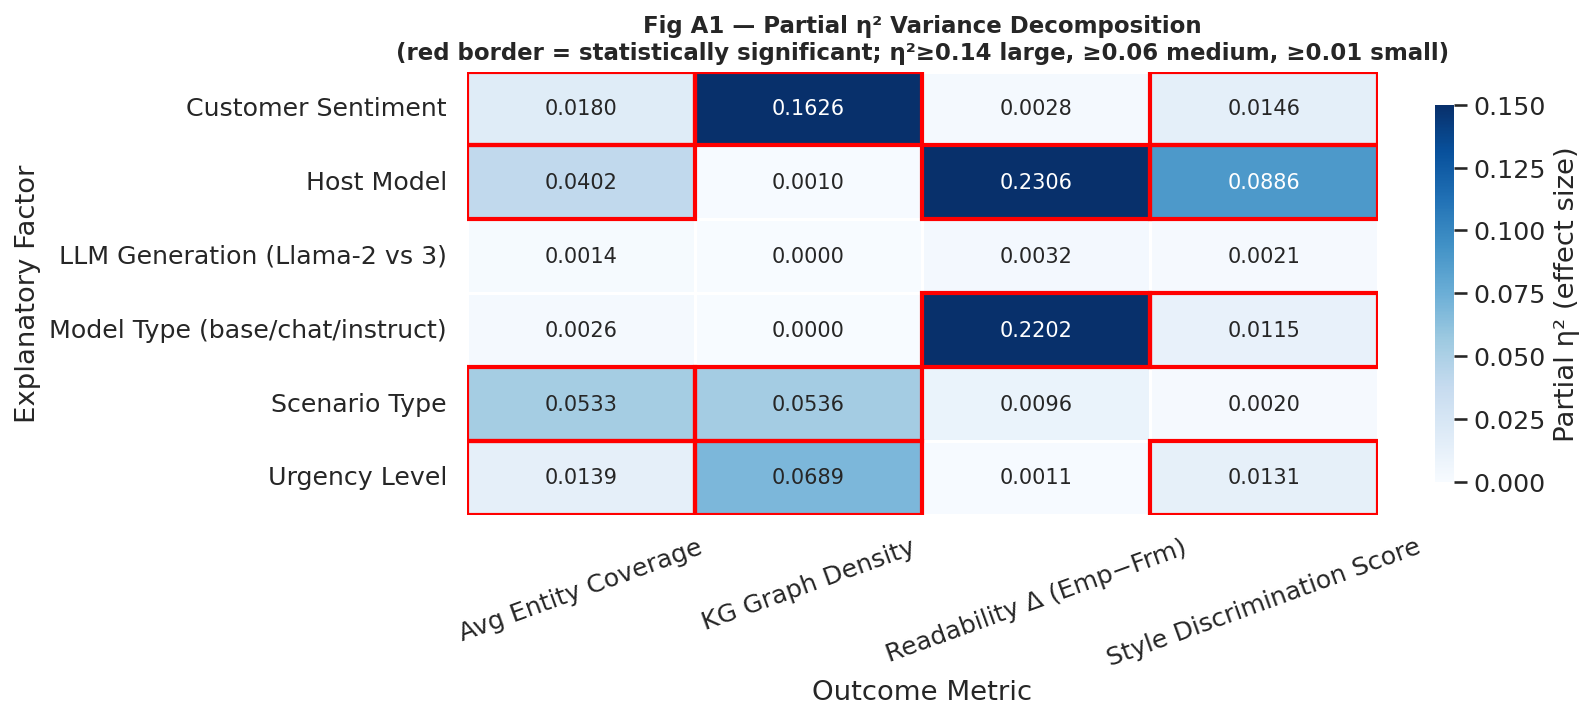

Saved figA1_variance_decomposition.pdf/png


In [6]:

# Heatmap of partial η² across factors × metrics
pivot_eta = eta2_df.pivot(index="Factor", columns="Metric", values="Partial η²")

fig, ax = plt.subplots(figsize=(11, 5))
sns.heatmap(pivot_eta, ax=ax, annot=True, fmt=".4f", cmap="Blues",
            linewidths=0.5, linecolor="white",
            vmin=0, vmax=0.15,
            annot_kws={"size": 10},
            cbar_kws={"label": "Partial η² (effect size)", "shrink": 0.85})

# Mark significance borders
for i, factor in enumerate(pivot_eta.index):
    for j, metric in enumerate(pivot_eta.columns):
        row = eta2_df[(eta2_df["Factor"]==factor) & (eta2_df["Metric"]==metric)]
        if not row.empty and row["Sig"].values[0] != "n.s.":
            ax.add_patch(plt.Rectangle((j, i), 1, 1, fill=False, edgecolor="red", lw=2))

ax.set_title("Fig A1 — Partial η² Variance Decomposition\n"
             "(red border = statistically significant; η²≥0.14 large, ≥0.06 medium, ≥0.01 small)",
             fontsize=11, fontweight="bold")
ax.set_xlabel("Outcome Metric"); ax.set_ylabel("Explanatory Factor")
ax.tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.savefig("figA1_variance_decomposition.pdf", bbox_inches="tight")
plt.savefig("figA1_variance_decomposition.png", dpi=200, bbox_inches="tight")
plt.show()
print("Saved figA1_variance_decomposition.pdf/png")


---
## B. Entity-Type Sparsity & Zero-Inflation Analysis

Entity coverage values are heavily zero-inflated — most outputs fail to recover any 
entity mention. This section:
1. Quantifies the **structural zero rate** per entity type and model
2. Fits a **hurdle/binary model**: P(any recovery) separately from E[coverage | recovery > 0]
3. Flags entity types that are **structurally unrecoverable** vs. merely rare

This is critical for DK-GenAI reviewers asking: *"Are your coverage numbers depressed by 
ontology mismatch or by model failure?"*


In [7]:

entity_types = {
    "product":       ("emp_cov_product",       "frm_cov_product"),
    "order_id":      ("emp_cov_order_id",       "frm_cov_order_id"),
    "issue":         ("emp_cov_issue",          "frm_cov_issue"),
    "urgency":       ("emp_cov_urgency",        "frm_cov_urgency"),
    "sentiment":     ("emp_cov_sentiment",      "frm_cov_sentiment"),
    "customer_name": ("emp_cov_customer_name",  "frm_cov_customer_name"),
}

sparsity_rows = []
for et, (emp_col, frm_col) in entity_types.items():
    for m in MODEL_ORDER:
        sub = df[df["model_short"]==m]
        for tone, col in [("Emp", emp_col), ("Frm", frm_col)]:
            vals = sub[col].fillna(0).values
            zero_rate = (vals == 0).mean()
            nonzero   = vals[vals > 0]
            cond_mean = nonzero.mean() if len(nonzero) > 0 else 0.0
            n_nonzero = len(nonzero)
            sparsity_rows.append({
                "Model": m, "EntityType": et.upper(), "Tone": tone,
                "Zero Rate": round(zero_rate, 4),
                "P(any recovery)": round(1 - zero_rate, 4),
                "Cond. Mean (given>0)": round(cond_mean, 4),
                "N recoveries": n_nonzero,
                "Structurally Zero": "YES" if zero_rate == 1.0 else ("near-zero" if zero_rate > 0.97 else "recoverable"),
            })

sparse_df = pd.DataFrame(sparsity_rows)

# Summary: entity-type level (aggregated over models)
et_summary = sparse_df.groupby(["EntityType","Tone"]).agg(
    Zero_Rate       = ("Zero Rate","mean"),
    P_recovery      = ("P(any recovery)","mean"),
    Cond_Mean       = ("Cond. Mean (given>0)","mean"),
    Total_recoveries= ("N recoveries","sum"),
).round(4).reset_index()

print("=== Entity-Type Sparsity Summary (aggregated over models) ===")
print(et_summary.to_string(index=False))
print()
print("=== Structurally Zero Entity Types ===")
print(sparse_df[sparse_df["Structurally Zero"]=="YES"][["Model","EntityType","Tone"]].drop_duplicates().to_string(index=False))
sparse_df.to_csv("tableB1_entity_sparsity.csv", index=False)


=== Entity-Type Sparsity Summary (aggregated over models) ===
   EntityType Tone  Zero_Rate  P_recovery  Cond_Mean  Total_recoveries
CUSTOMER_NAME  Emp     0.9933      0.0067     0.2083                 4
CUSTOMER_NAME  Frm     0.9967      0.0033     0.1667                 2
        ISSUE  Emp     0.9933      0.0067     0.1667                 4
        ISSUE  Frm     0.9900      0.0100     0.4444                 6
     ORDER_ID  Emp     0.9900      0.0100     0.3333                 6
     ORDER_ID  Frm     0.9667      0.0333     0.5000                20
      PRODUCT  Emp     0.9600      0.0400     0.3471                24
      PRODUCT  Frm     0.9733      0.0267     0.2976                16
    SENTIMENT  Emp     1.0000      0.0000     0.0000                 0
    SENTIMENT  Frm     0.9983      0.0017     0.1667                 1
      URGENCY  Emp     0.9317      0.0683     1.0000                41
      URGENCY  Frm     0.9017      0.0983     1.0000                59

=== Structural

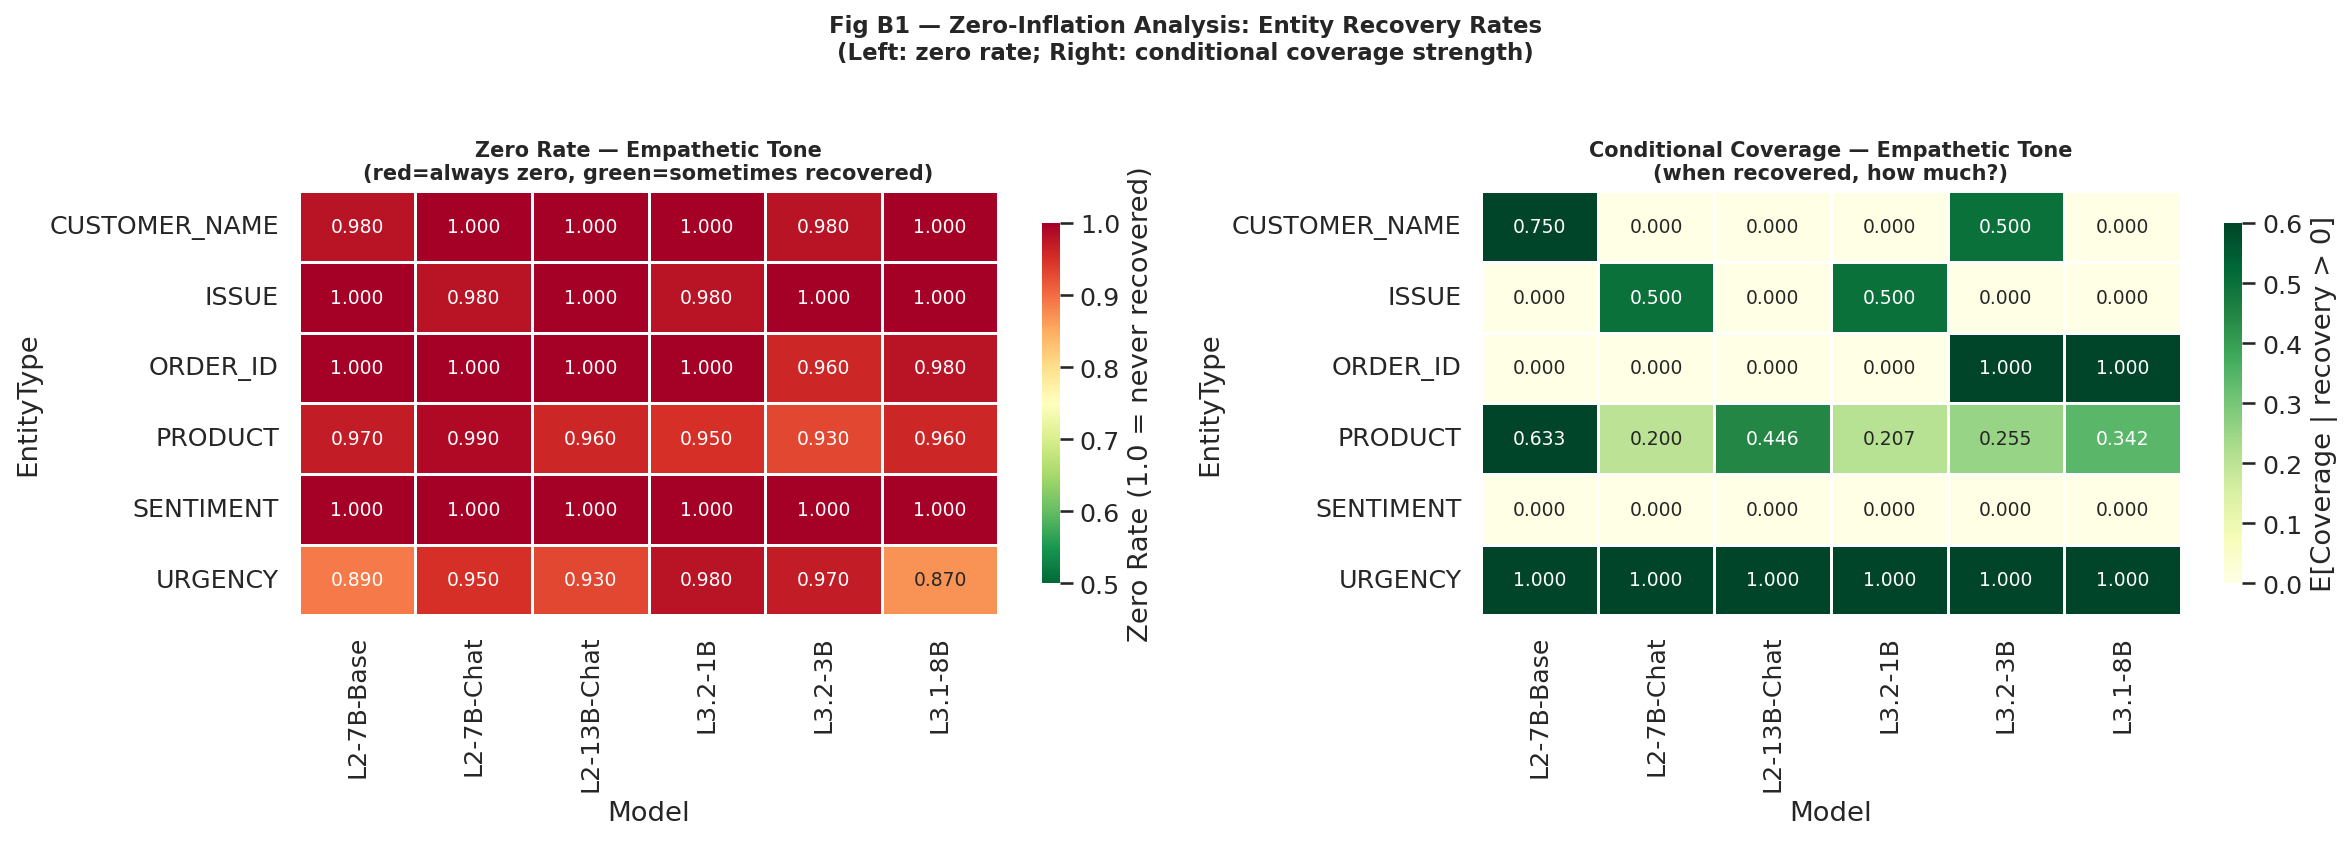

Saved figB1_zero_inflation.pdf/png


In [8]:

fig, axes = plt.subplots(1, 2, figsize=(16, 5.5))

# Panel A: zero-rate heatmap (emp)
emp_pivot = sparse_df[sparse_df["Tone"]=="Emp"].pivot(
    index="EntityType", columns="Model", values="Zero Rate")
emp_pivot = emp_pivot[MODEL_ORDER]

sns.heatmap(emp_pivot, ax=axes[0], annot=True, fmt=".3f", cmap="RdYlGn_r",
            linewidths=0.5, vmin=0.5, vmax=1.0,
            annot_kws={"size": 9},
            cbar_kws={"label":"Zero Rate (1.0 = never recovered)","shrink":0.85})
axes[0].set_title("Zero Rate — Empathetic Tone\n(red=always zero, green=sometimes recovered)",
                  fontsize=10, fontweight="bold")

# Panel B: conditional mean (given any recovery) — emp
cond_pivot = sparse_df[sparse_df["Tone"]=="Emp"].pivot(
    index="EntityType", columns="Model", values="Cond. Mean (given>0)")
cond_pivot = cond_pivot[MODEL_ORDER]

sns.heatmap(cond_pivot, ax=axes[1], annot=True, fmt=".3f", cmap="YlGn",
            linewidths=0.5, vmin=0, vmax=0.6,
            annot_kws={"size": 9},
            cbar_kws={"label":"E[Coverage | recovery > 0]","shrink":0.85})
axes[1].set_title("Conditional Coverage — Empathetic Tone\n(when recovered, how much?)",
                  fontsize=10, fontweight="bold")

plt.suptitle("Fig B1 — Zero-Inflation Analysis: Entity Recovery Rates\n"
             "(Left: zero rate; Right: conditional coverage strength)",
             fontsize=11, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("figB1_zero_inflation.pdf", bbox_inches="tight")
plt.savefig("figB1_zero_inflation.png", dpi=200, bbox_inches="tight")
plt.show()
print("Saved figB1_zero_inflation.pdf/png")


---
## C. Ordinal Urgency–Coverage Regression (Jonckheere-Terpstra Trend Test)

The KG encodes `urgency` as a node. If the KG pipeline is working, *higher urgency* 
inputs should produce *more urgency-node activations*, which should translate into 
**higher URGENCY entity coverage**. We test this ordered trend using the 
**Jonckheere-Terpstra (J-T) test** — the non-parametric equivalent of a linear trend 
across ordered groups.

A significant positive J-T statistic would confirm that urgency is encoded 
and recovered in the right direction.


In [9]:

# Manual J-T test (not in scipy directly)
def jonckheere_terpstra(groups):
    """
    J-T test for ordered alternatives.
    groups: list of arrays in order low → high
    Returns: J_stat (sum of pairwise Mann-Whitney U), z-score, p-value (two-sided)
    """
    k = len(groups)
    J = 0
    for i in range(k - 1):
        for j in range(i + 1, k):
            u, _ = mannwhitneyu(groups[i], groups[j], alternative="less")
            J += u
    # Expected value and variance under H0
    N = sum(len(g) for g in groups)
    n = [len(g) for g in groups]
    E_J = (N**2 - sum(ni**2 for ni in n)) / 4
    # Approximate variance (tie-corrected version not implemented; use basic)
    term1 = N**2 * (2*N + 3)
    term2 = sum(ni**2 * (2*ni + 3) for ni in n)
    V_J   = (term1 - term2) / 72
    z = (J - E_J) / (np.sqrt(V_J) + 1e-9)
    p = 2 * (1 - stats.norm.cdf(abs(z)))  # two-sided
    return J, z, p

URGENCY_ORDER = ["low", "medium", "high"]
targets = {
    "emp_cov_urgency":  "URGENCY Entity Cov (Emp)",
    "avg_entity_cov":   "Avg Entity Coverage",
    "emp_entity_cov":   "Overall Entity Cov (Emp)",
    "emp_empathy_score":"Empathy Score (Emp)",
    "style_disc_score": "Style Disc. Score",
}

jt_rows = []
for m in MODEL_ORDER + ["ALL"]:
    sub = df if m == "ALL" else df[df["model_short"]==m]
    for col, label in targets.items():
        groups = [sub[sub["urgency"]==u][col].fillna(0).values for u in URGENCY_ORDER]
        J, z, p = jonckheere_terpstra(groups)
        group_means = [g.mean() for g in groups]
        jt_rows.append({
            "Model": m, "Target": label,
            "Mean(low)": round(group_means[0], 5),
            "Mean(med)": round(group_means[1], 5),
            "Mean(high)": round(group_means[2], 5),
            "J-T Stat": round(J, 1),
            "z": round(z, 3),
            "p (J-T)": round(p, 5),
            "Trend": "↑ positive ***" if (p < 0.05 and z > 0) else
                     ("↓ negative *" if (p < 0.05 and z < 0) else "n.s."),
        })

jt_df = pd.DataFrame(jt_rows)
print("=== Jonckheere-Terpstra Trend Test: Urgency → Coverage ===")
print(jt_df.to_string(index=False))
jt_df.to_csv("tableC1_urgency_trend_test.csv", index=False)
print("\nSaved tableC1_urgency_trend_test.csv")


=== Jonckheere-Terpstra Trend Test: Urgency → Coverage ===
      Model                   Target  Mean(low)  Mean(med)  Mean(high)  J-T Stat      z  p (J-T)          Trend
 L2-7B-Base URGENCY Entity Cov (Emp)    0.16667    0.00000     0.14000    1539.0 -0.149  0.88122           n.s.
 L2-7B-Base      Avg Entity Coverage    0.02530    0.00549     0.01702    1546.0 -0.104  0.91721           n.s.
 L2-7B-Base Overall Entity Cov (Emp)    0.04464    0.00549     0.02290    1577.0  0.097  0.92237           n.s.
 L2-7B-Base      Empathy Score (Emp)    0.01882    0.01985     0.01613    1597.0  0.227  0.82013           n.s.
 L2-7B-Base        Style Disc. Score    0.02100    0.02965     0.01293    1747.0  1.202  0.22942           n.s.
 L2-7B-Chat URGENCY Entity Cov (Emp)    0.00000    0.07692     0.06000    1513.0 -0.318  0.75023           n.s.
 L2-7B-Chat      Avg Entity Coverage    0.02046    0.01385     0.01665    1620.0  0.377  0.70632           n.s.
 L2-7B-Chat Overall Entity Cov (Emp)    0.011

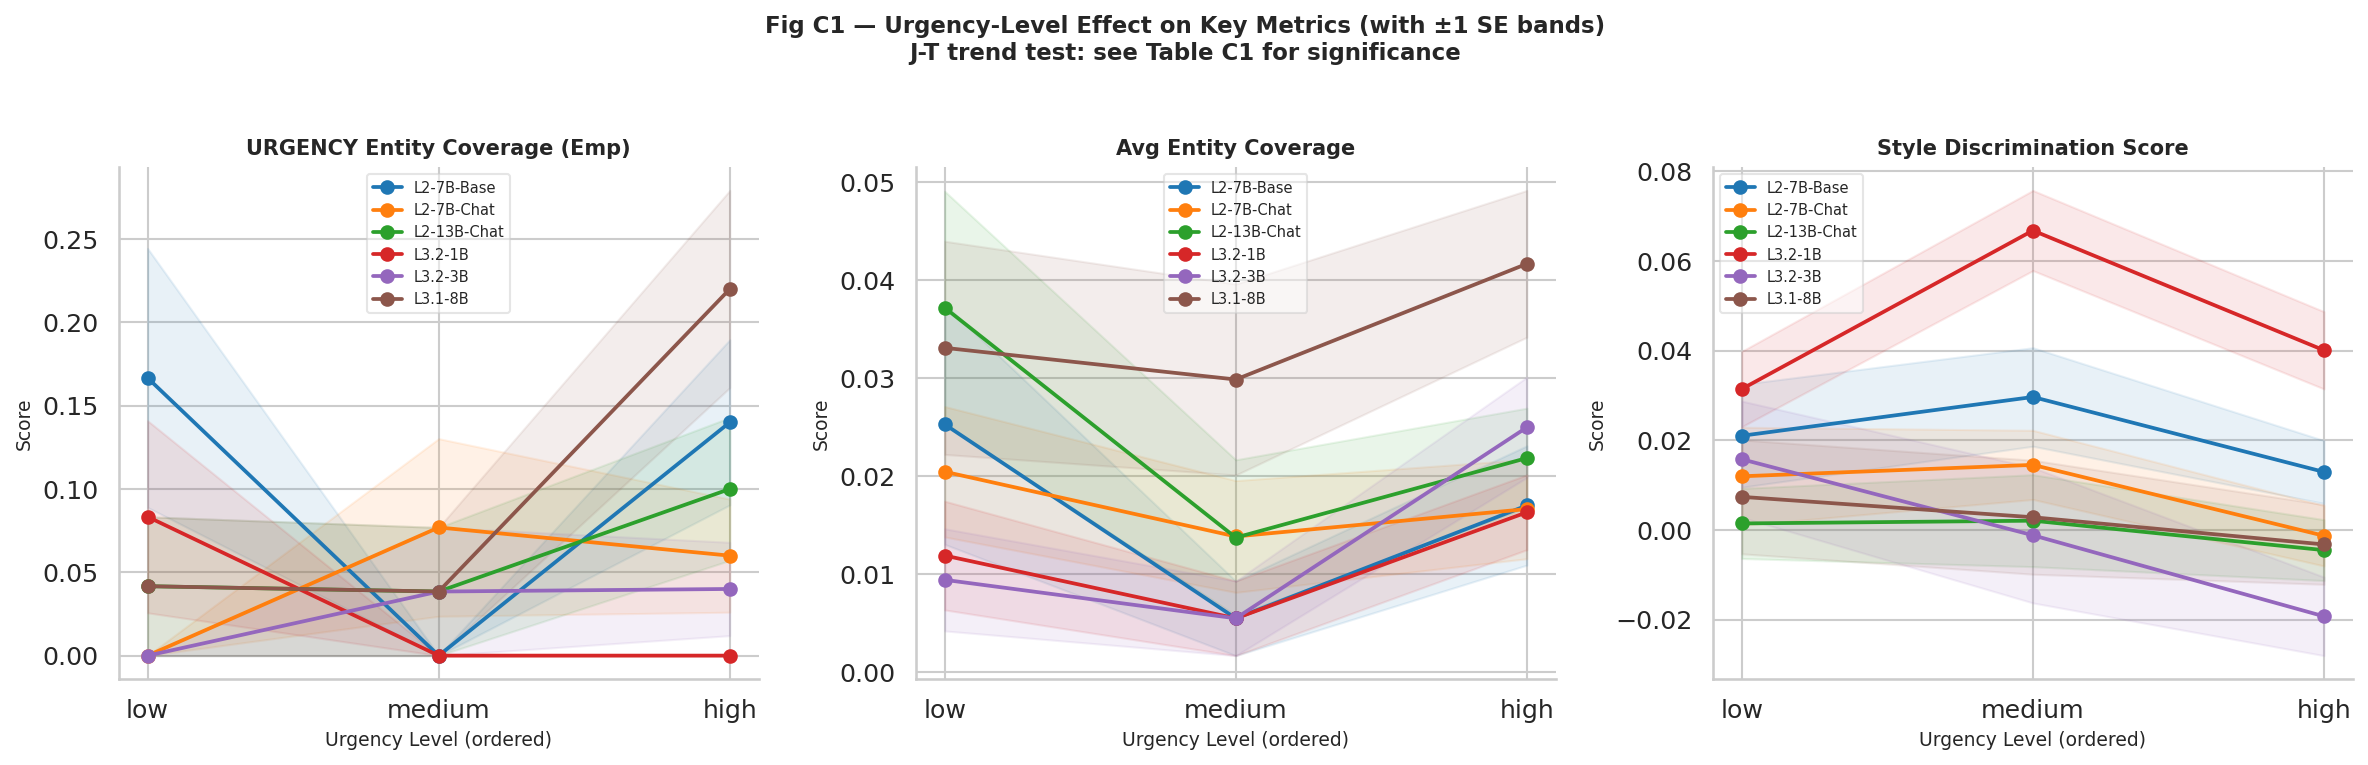

Saved figC1_urgency_trend.pdf/png


In [10]:

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

target_plots = [
    ("emp_cov_urgency", "URGENCY Entity Coverage (Emp)"),
    ("avg_entity_cov",  "Avg Entity Coverage"),
    ("style_disc_score","Style Discrimination Score"),
]

for ax, (col, label) in zip(axes, target_plots):
    for m in MODEL_ORDER:
        sub = df[df["model_short"]==m]
        means = [sub[sub["urgency"]==u][col].fillna(0).mean() for u in URGENCY_ORDER]
        sems  = [sub[sub["urgency"]==u][col].fillna(0).sem()  for u in URGENCY_ORDER]
        ax.plot(URGENCY_ORDER, means, marker="o", color=PALETTE[m], label=m, lw=1.8)
        ax.fill_between(URGENCY_ORDER,
                        [m_-s for m_,s in zip(means,sems)],
                        [m_+s for m_,s in zip(means,sems)],
                        color=PALETTE[m], alpha=0.10)
    ax.set_title(label, fontsize=10, fontweight="bold")
    ax.set_xlabel("Urgency Level (ordered)", fontsize=9)
    ax.set_ylabel("Score", fontsize=9)
    ax.legend(fontsize=7, framealpha=0.5)

plt.suptitle("Fig C1 — Urgency-Level Effect on Key Metrics (with ±1 SE bands)\n"
             "J-T trend test: see Table C1 for significance",
             fontsize=11, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("figC1_urgency_trend.pdf", bbox_inches="tight")
plt.savefig("figC1_urgency_trend.png", dpi=200, bbox_inches="tight")
plt.show()
print("Saved figC1_urgency_trend.pdf/png")


---
## D. Tone × Scenario Interaction Analysis

Does the **style effect** (empathetic vs formal) interact with the **scenario type**?  
For example, does a `billing_error` scenario suppress empathy scores in ways that 
`delivery_delay` does not? A significant **Tone × Scenario interaction** would mean 
the KG-gating effect is scenario-conditional — an important nuance for DK-GenAI.

We test this via a **2-way interaction t-test** and **interaction plots** per model.


In [11]:

SCENARIOS = ["battery_issue", "wrong_item", "billing_error", "delivery_delay"]
TONES = ["emp", "frm"]

int_rows = []
for m in MODEL_ORDER:
    sub_m = df[df["model_short"]==m]
    for sc in SCENARIOS:
        sub_sc = sub_m[sub_m["scenario"]==sc]
        emp_vals = sub_sc["emp_entity_cov"].fillna(0).values
        frm_vals = sub_sc["frm_entity_cov"].fillna(0).values
        if len(emp_vals) > 1:
            t, p = ttest_rel(emp_vals, frm_vals)
            diff  = emp_vals - frm_vals
            d = diff.mean() / (diff.std() + 1e-9)
        else:
            t, p, d = np.nan, np.nan, np.nan
        int_rows.append({
            "Model": m, "Scenario": sc,
            "Emp Mean": round(emp_vals.mean(), 5),
            "Frm Mean": round(frm_vals.mean(), 5),
            "Δ (E−F)":  round((emp_vals-frm_vals).mean(), 5),
            "Cohen's d": round(d, 3) if not np.isnan(d) else np.nan,
            "t-stat":   round(t, 3)  if not np.isnan(t) else np.nan,
            "p (paired)": round(p, 5) if not np.isnan(p) else np.nan,
            "Sig": ("***" if p<0.001 else ("**" if p<0.01 else ("*" if p<0.05 else "n.s.")))
                   if not np.isnan(p) else "n/a",
        })

int_df = pd.DataFrame(int_rows)
print("=== Tone × Scenario Interaction: Entity Coverage (Emp − Frm) ===")
print(int_df.to_string(index=False))
int_df.to_csv("tableD1_tone_scenario_interaction.csv", index=False)
print("\nSaved tableD1_tone_scenario_interaction.csv")


=== Tone × Scenario Interaction: Entity Coverage (Emp − Frm) ===
      Model       Scenario  Emp Mean  Frm Mean  Δ (E−F)  Cohen's d  t-stat  p (paired)  Sig
 L2-7B-Base  battery_issue   0.01714   0.00571  0.01143      0.295   1.445     0.16149 n.s.
 L2-7B-Base     wrong_item   0.02451   0.01227  0.01224      0.205   1.005     0.32488 n.s.
 L2-7B-Base  billing_error   0.01771   0.00000  0.01771      0.354   1.735     0.09561 n.s.
 L2-7B-Base delivery_delay   0.03500   0.01571  0.01929      0.183   0.898     0.37810 n.s.
 L2-7B-Chat  battery_issue   0.01516   0.00444  0.01071      0.294   1.441     0.16246 n.s.
 L2-7B-Chat     wrong_item   0.00571   0.00905 -0.00333     -0.076  -0.375     0.71117 n.s.
 L2-7B-Chat  billing_error   0.00000   0.01714 -0.01714     -0.369  -1.809     0.08299 n.s.
 L2-7B-Chat delivery_delay   0.02268   0.06050 -0.03781     -0.452  -2.212     0.03672    *
L2-13B-Chat  battery_issue   0.01905   0.02286 -0.00381     -0.048  -0.235     0.81595 n.s.
L2-13B-Chat    

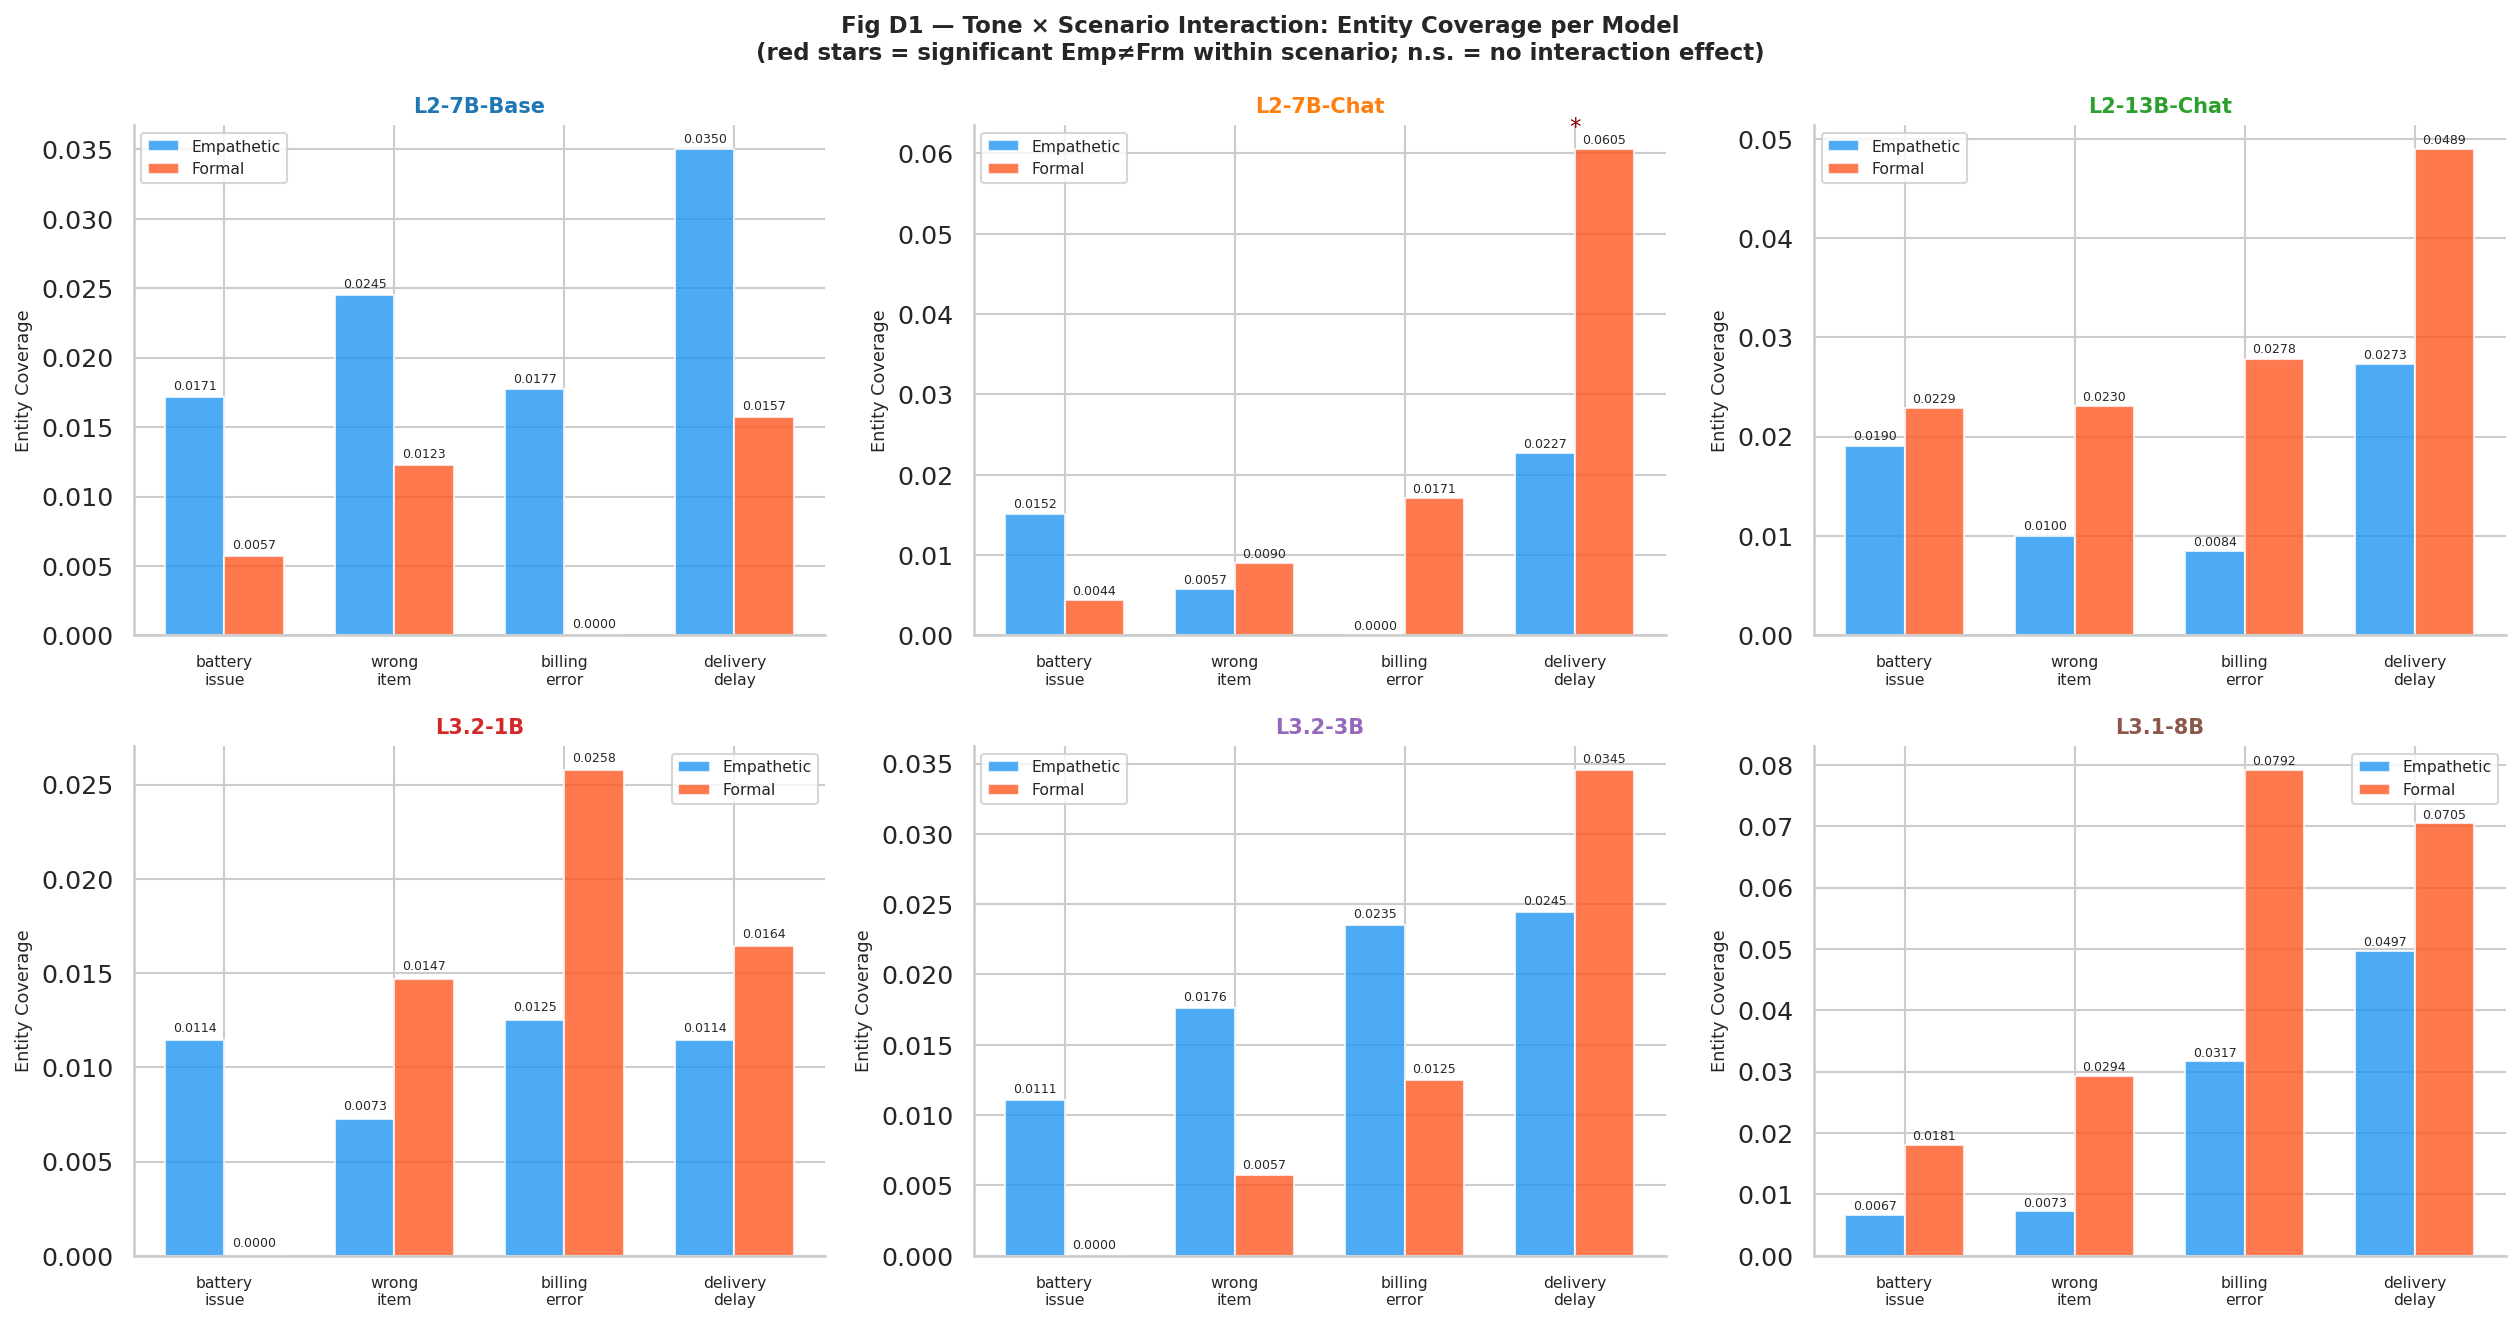

Saved figD1_tone_scenario_interaction.pdf/png


In [13]:
fig, axes = plt.subplots(2, 3, figsize=(17, 9))
axes = axes.flatten()

for i, m in enumerate(MODEL_ORDER):
    ax = axes[i]
    sub_m = df[df["model_short"]==m]
    emp_means = [sub_m[sub_m["scenario"]==sc]["emp_entity_cov"].fillna(0).mean() for sc in SCENARIOS]
    frm_means = [sub_m[sub_m["scenario"]==sc]["frm_entity_cov"].fillna(0).mean() for sc in SCENARIOS]

    x = np.arange(len(SCENARIOS))
    w = 0.35
    b1 = ax.bar(x - w/2, emp_means, width=w, label="Empathetic", color="#2196F3", alpha=0.8)
    b2 = ax.bar(x + w/2, frm_means, width=w, label="Formal",     color="#FF5722", alpha=0.8)

    # Annotate sig stars from int_df
    for j, sc in enumerate(SCENARIOS):
        sig_val = int_df[(int_df["Model"]==m)&(int_df["Scenario"]==sc)]["Sig"].values
        if sig_val.size and sig_val[0] not in ("n.s.", "n/a"):
            y_top = max(emp_means[j], frm_means[j]) + 0.002
            ax.text(j, y_top, sig_val[0], ha="center", fontsize=11, color="darkred")

    ax.set_title(m, fontsize=10, fontweight="bold", color=PALETTE[m])
    ax.set_xticks(x)
    ax.set_xticklabels([s.replace("_", "\n") for s in SCENARIOS], fontsize=7.5)  # ← fixed
    ax.set_ylabel("Entity Coverage", fontsize=8.5)
    ax.legend(fontsize=7.5)
    for bar in list(b1) + list(b2):
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.0003, f"{h:.4f}",
                ha="center", va="bottom", fontsize=6)

plt.suptitle("Fig D1 — Tone × Scenario Interaction: Entity Coverage per Model\n"
             "(red stars = significant Emp≠Frm within scenario; n.s. = no interaction effect)",
             fontsize=11, fontweight="bold")
plt.tight_layout()
plt.savefig("figD1_tone_scenario_interaction.pdf", bbox_inches="tight")
plt.savefig("figD1_tone_scenario_interaction.png", dpi=200, bbox_inches="tight")
plt.show()
print("Saved figD1_tone_scenario_interaction.pdf/png")

---
## E. Cross-Generation Contrast: Llama-2 vs Llama-3

DK-GenAI reviewers will ask whether the framework generalises across LLM generations.  
Here we directly contrast the **Llama-2** family (L2-7B-Base, L2-7B-Chat, L2-13B-Chat) 
vs **Llama-3** family (L3.2-1B, L3.2-3B, L3.1-8B) on all key metrics using 
**independent-samples t-tests with Welch correction** and compute effect sizes.

Key claim to support: *"The KG-gating benefit is generation-agnostic."*


In [14]:

llama2 = df[df["generation"] == "Llama-2"]
llama3 = df[df["generation"] == "Llama-3"]

gen_metrics = {
    "avg_entity_cov":    "Avg Entity Coverage",
    "emp_entity_cov":    "Entity Coverage (Emp)",
    "frm_entity_cov":    "Entity Coverage (Frm)",
    "style_disc_score":  "Style Discrimination",
    "emp_flesch_ease":   "Flesch Ease (Emp)",
    "frm_flesch_ease":   "Flesch Ease (Frm)",
    "flesch_delta":      "Readability Δ (Emp−Frm)",
    "emp_ttr":           "Type-Token Ratio (Emp)",
    "emp_empathy_score": "Empathy Score (Emp)",
    "frm_formality_score":"Formality Score (Frm)",
    "kg_nodes":          "KG Node Count",
    "kg_density":        "KG Density",
    "kg_salience":       "KG Mean Salience",
}

gen_rows = []
for col, label in gen_metrics.items():
    v2 = llama2[col].fillna(0).values
    v3 = llama3[col].fillna(0).values
    t, p = ttest_ind(v2, v3, equal_var=False)  # Welch
    d_cohen = (v2.mean() - v3.mean()) / (
        np.sqrt((v2.std()**2 + v3.std()**2) / 2) + 1e-9)
    # Bootstrap CI on difference in means
    np.random.seed(42)
    boot_diffs = [np.random.choice(v2,len(v2),replace=True).mean() -
                  np.random.choice(v3,len(v3),replace=True).mean()
                  for _ in range(5000)]
    ci_lo, ci_hi = np.percentile(boot_diffs, [2.5, 97.5])
    gen_rows.append({
        "Metric": label,
        "Llama-2 Mean": round(v2.mean(), 5),
        "Llama-3 Mean": round(v3.mean(), 5),
        "Δ (L2−L3)":   round(v2.mean()-v3.mean(), 5),
        "95% CI lo":   round(ci_lo, 5),
        "95% CI hi":   round(ci_hi, 5),
        "Cohen's d":   round(d_cohen, 3),
        "t (Welch)":   round(t, 3),
        "p-value":     round(p, 6),
        "Sig": "***" if p<0.001 else ("**" if p<0.01 else ("*" if p<0.05 else "n.s.")),
        "Supports Gen-Agnostic": "✓" if abs(d_cohen) < 0.2 else "⚠ effect",
    })

gen_df = pd.DataFrame(gen_rows)
print("=== Cross-Generation Contrast: Llama-2 vs Llama-3 ===")
print(gen_df.to_string(index=False))
gen_df.to_csv("tableE1_generation_contrast.csv", index=False)
print("\nSaved tableE1_generation_contrast.csv")


=== Cross-Generation Contrast: Llama-2 vs Llama-3 ===
                 Metric  Llama-2 Mean  Llama-3 Mean  Δ (L2−L3)  95% CI lo  95% CI hi  Cohen's d  t (Welch)  p-value  Sig Supports Gen-Agnostic
    Avg Entity Coverage       0.01876       0.02173   -0.00297   -0.00944    0.00338     -0.075     -0.913 0.361862 n.s.                     ✓
  Entity Coverage (Emp)       0.01689       0.01789   -0.00100   -0.00896    0.00715     -0.020     -0.241 0.809873 n.s.                     ✓
  Entity Coverage (Frm)       0.02062       0.02557   -0.00495   -0.01444    0.00412     -0.087     -1.063 0.288342 n.s.                     ✓
   Style Discrimination       0.00794       0.01321   -0.00528   -0.01475    0.00400     -0.091     -1.112 0.266753 n.s.                     ✓
      Flesch Ease (Emp)      49.81144      41.40879    8.40266    6.14922   10.65435      0.587      7.183 0.000000  ***              ⚠ effect
      Flesch Ease (Frm)      39.82191      33.70862    6.11329    3.59099    8.49248    

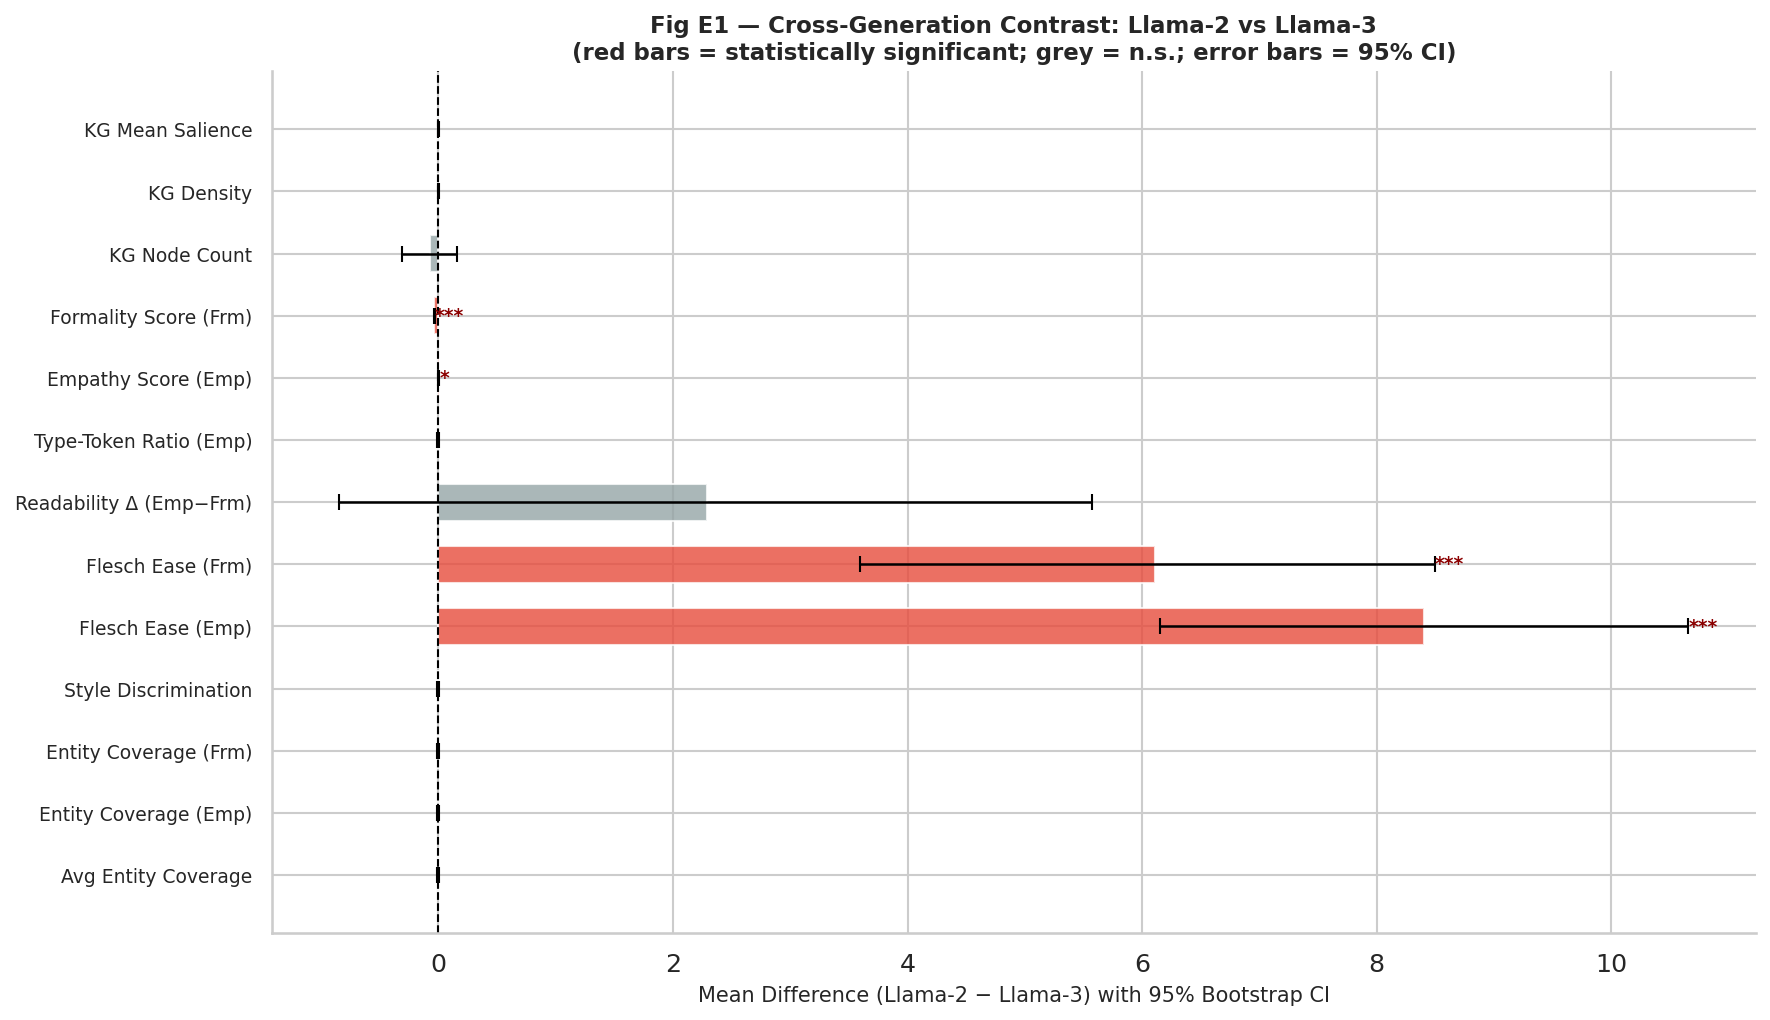

Saved figE1_generation_contrast.pdf/png


In [15]:

fig, ax = plt.subplots(figsize=(12, 7))

y_pos = np.arange(len(gen_df))
colors = ["#e74c3c" if row["Sig"] != "n.s." else "#95a5a6"
          for _, row in gen_df.iterrows()]

ax.barh(y_pos, gen_df["Δ (L2−L3)"], color=colors, height=0.6, alpha=0.8)
ax.errorbar(gen_df["Δ (L2−L3)"], y_pos,
            xerr=[gen_df["Δ (L2−L3)"] - gen_df["95% CI lo"],
                  gen_df["95% CI hi"] - gen_df["Δ (L2−L3)"]],
            fmt="none", color="black", capsize=4, lw=1.2)

ax.axvline(0, color="black", lw=1.0, ls="--")
ax.set_yticks(y_pos)
ax.set_yticklabels(gen_df["Metric"], fontsize=9)
ax.set_xlabel("Mean Difference (Llama-2 − Llama-3) with 95% Bootstrap CI", fontsize=10)
ax.set_title("Fig E1 — Cross-Generation Contrast: Llama-2 vs Llama-3\n"
             "(red bars = statistically significant; grey = n.s.; error bars = 95% CI)",
             fontsize=11, fontweight="bold")

# Annotate sig
for i, (_, row) in enumerate(gen_df.iterrows()):
    if row["Sig"] != "n.s.":
        ax.text(row["95% CI hi"] + 0.0001, i, row["Sig"],
                va="center", fontsize=9, color="darkred", fontweight="bold")

plt.tight_layout()
plt.savefig("figE1_generation_contrast.pdf", bbox_inches="tight")
plt.savefig("figE1_generation_contrast.png", dpi=200, bbox_inches="tight")
plt.show()
print("Saved figE1_generation_contrast.pdf/png")


---
## F. KG Graph Efficiency Frontier — Coverage per Graph Complexity

**Research question:** Is a more complex KG (more nodes/edges) always better?  
We plot an **efficiency frontier** of entity coverage vs KG size (nodes, edges, density),  
and identify whether any models achieve *high coverage from sparse KGs* (efficient)  
vs *low coverage from dense KGs* (inefficient).

This is the key DK-GenAI "knowledge structure" contribution.


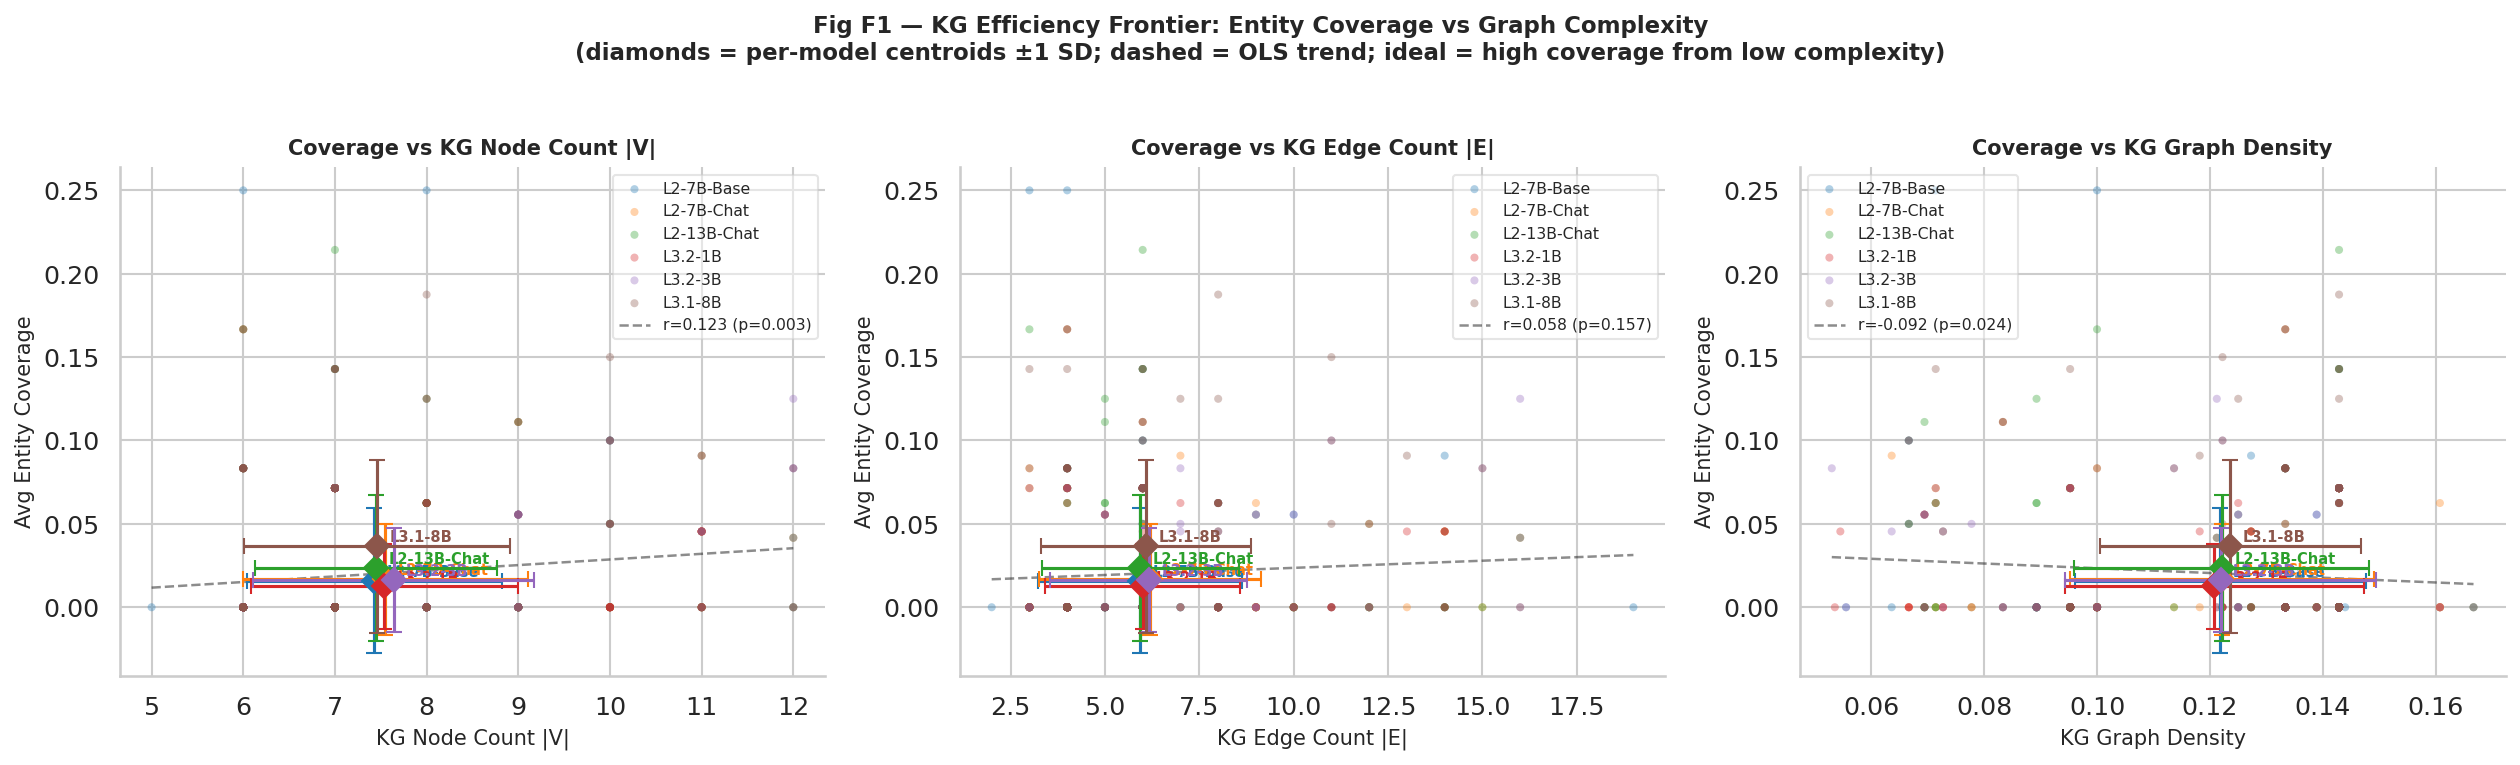

Saved figF1_kg_efficiency_frontier.pdf/png

=== KG Coverage Efficiency (coverage / node) ===
                 mean       std
model_short                    
L2-13B-Chat  0.003216  0.006248
L2-7B-Base   0.002116  0.006145
L2-7B-Chat   0.002264  0.004726
L3.1-8B      0.004967  0.007299
L3.2-1B      0.001594  0.003393
L3.2-3B      0.001911  0.003782


In [16]:

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

kg_x_vars = [
    ("kg_nodes",   "KG Node Count |V|"),
    ("kg_edges",   "KG Edge Count |E|"),
    ("kg_density", "KG Graph Density"),
]

for ax, (x_col, x_label) in zip(axes, kg_x_vars):
    # Scatter by model
    for m in MODEL_ORDER:
        sub = df[df["model_short"]==m]
        ax.scatter(sub[x_col], sub["avg_entity_cov"],
                   color=PALETTE[m], alpha=0.35, s=15, label=m, edgecolors="none")

    # Per-model centroids with error bars
    for m in MODEL_ORDER:
        sub = df[df["model_short"]==m]
        mx = sub[x_col].mean(); my = sub["avg_entity_cov"].mean()
        sx = sub[x_col].std();  sy = sub["avg_entity_cov"].std()
        ax.errorbar(mx, my, xerr=sx, yerr=sy,
                    color=PALETTE[m], fmt="D", ms=8, lw=1.5, capsize=4, zorder=10)
        ax.annotate(m, (mx, my), textcoords="offset points",
                    xytext=(6, 2), fontsize=7, color=PALETTE[m], fontweight="bold")

    # Fit trend line
    x_all = df[x_col].fillna(0).values
    y_all = df["avg_entity_cov"].fillna(0).values
    r, p  = pearsonr(x_all, y_all)
    z     = np.polyfit(x_all, y_all, 1)
    p_fn  = np.poly1d(z)
    x_line = np.linspace(x_all.min(), x_all.max(), 100)
    ax.plot(x_line, p_fn(x_line), "k--", lw=1.2, alpha=0.5,
            label=f"r={r:.3f} (p={'<.001' if p<0.001 else f'{p:.3f}'})")

    ax.set_xlabel(x_label, fontsize=10)
    ax.set_ylabel("Avg Entity Coverage", fontsize=10)
    ax.set_title(f"Coverage vs {x_label}", fontsize=10, fontweight="bold")
    ax.legend(fontsize=7.5, framealpha=0.5)

plt.suptitle("Fig F1 — KG Efficiency Frontier: Entity Coverage vs Graph Complexity\n"
             "(diamonds = per-model centroids ±1 SD; dashed = OLS trend; "
             "ideal = high coverage from low complexity)",
             fontsize=11, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("figF1_kg_efficiency_frontier.pdf", bbox_inches="tight")
plt.savefig("figF1_kg_efficiency_frontier.png", dpi=200, bbox_inches="tight")
plt.show()
print("Saved figF1_kg_efficiency_frontier.pdf/png")

# Coverage-per-node efficiency metric
df["coverage_per_node"] = df["avg_entity_cov"] / (df["kg_nodes"] + 1e-9)
eff = df.groupby("model_short")["coverage_per_node"].agg(["mean","std"]).round(6)
print("\n=== KG Coverage Efficiency (coverage / node) ===")
print(eff.to_string())


---
## G. Style Calibration Error (SCE) — Novel Diagnostic Metric

**Style Calibration Error** measures the gap between *intended* and *achieved* tone:

```
SCE_emp = |emp_empathy_score − expected_empathy|
SCE_frm = |frm_formality_score − expected_formality|
```

Since we lack gold-standard expected values, we use **the model's own maximum** 
as the calibration target (best-case baseline within the corpus). SCE = 0 means 
the model hit its personal best on every output.

This novel metric captures *consistency of style execution*, separate from 
style *discrimination* (already in style_disc_score).


In [17]:

# SCE: distance from each model's own 90th-percentile ceiling (attainable upper bound)
sce_rows = []
for m in MODEL_ORDER:
    sub = df[df["model_short"]==m]

    emp90 = sub["emp_empathy_score"].quantile(0.90)
    frm90 = sub["frm_formality_score"].quantile(0.90)

    sce_emp = abs(sub["emp_empathy_score"] - emp90).mean()
    sce_frm = abs(sub["frm_formality_score"] - frm90).mean()
    sce_avg = (sce_emp + sce_frm) / 2

    # How often does the model hit ≥75th percentile on both tones simultaneously?
    hit_rate = ((sub["emp_empathy_score"] >= sub["emp_empathy_score"].quantile(0.75)) &
                (sub["frm_formality_score"] >= sub["frm_formality_score"].quantile(0.75))).mean()

    sce_rows.append({
        "Model": m,
        "SCE (Emp)": round(sce_emp, 6),
        "SCE (Frm)": round(sce_frm, 6),
        "SCE (Avg)": round(sce_avg, 6),
        "Ceiling Emp (90th pct)": round(emp90, 5),
        "Ceiling Frm (90th pct)": round(frm90, 5),
        "Dual-Peak Hit Rate": round(hit_rate, 4),
        "Interpretation": ("good" if sce_avg < 0.015 else
                           "moderate" if sce_avg < 0.03 else "poor"),
    })

sce_df = pd.DataFrame(sce_rows)
print("=== Style Calibration Error (SCE) per Model ===")
print(sce_df.to_string(index=False))
sce_df.to_csv("tableG1_style_calibration_error.csv", index=False)
print("\nSaved tableG1_style_calibration_error.csv")


=== Style Calibration Error (SCE) per Model ===
      Model  SCE (Emp)  SCE (Frm)  SCE (Avg)  Ceiling Emp (90th pct)  Ceiling Frm (90th pct)  Dual-Peak Hit Rate Interpretation
 L2-7B-Base   0.046774   0.042069   0.044422                 0.06452                 0.06897                0.27           poor
 L2-7B-Chat   0.024839   0.050690   0.037764                 0.03226                 0.07241                0.11           poor
L2-13B-Chat   0.026129   0.046897   0.036513                 0.03226                 0.06897                0.14           poor
    L3.2-1B   0.053226   0.040690   0.046958                 0.06452                 0.10690                0.37           poor
    L3.2-3B   0.028387   0.052759   0.040573                 0.03226                 0.10690                0.27           poor
    L3.1-8B   0.026129   0.045862   0.035996                 0.03226                 0.10345                0.26           poor

Saved tableG1_style_calibration_error.csv


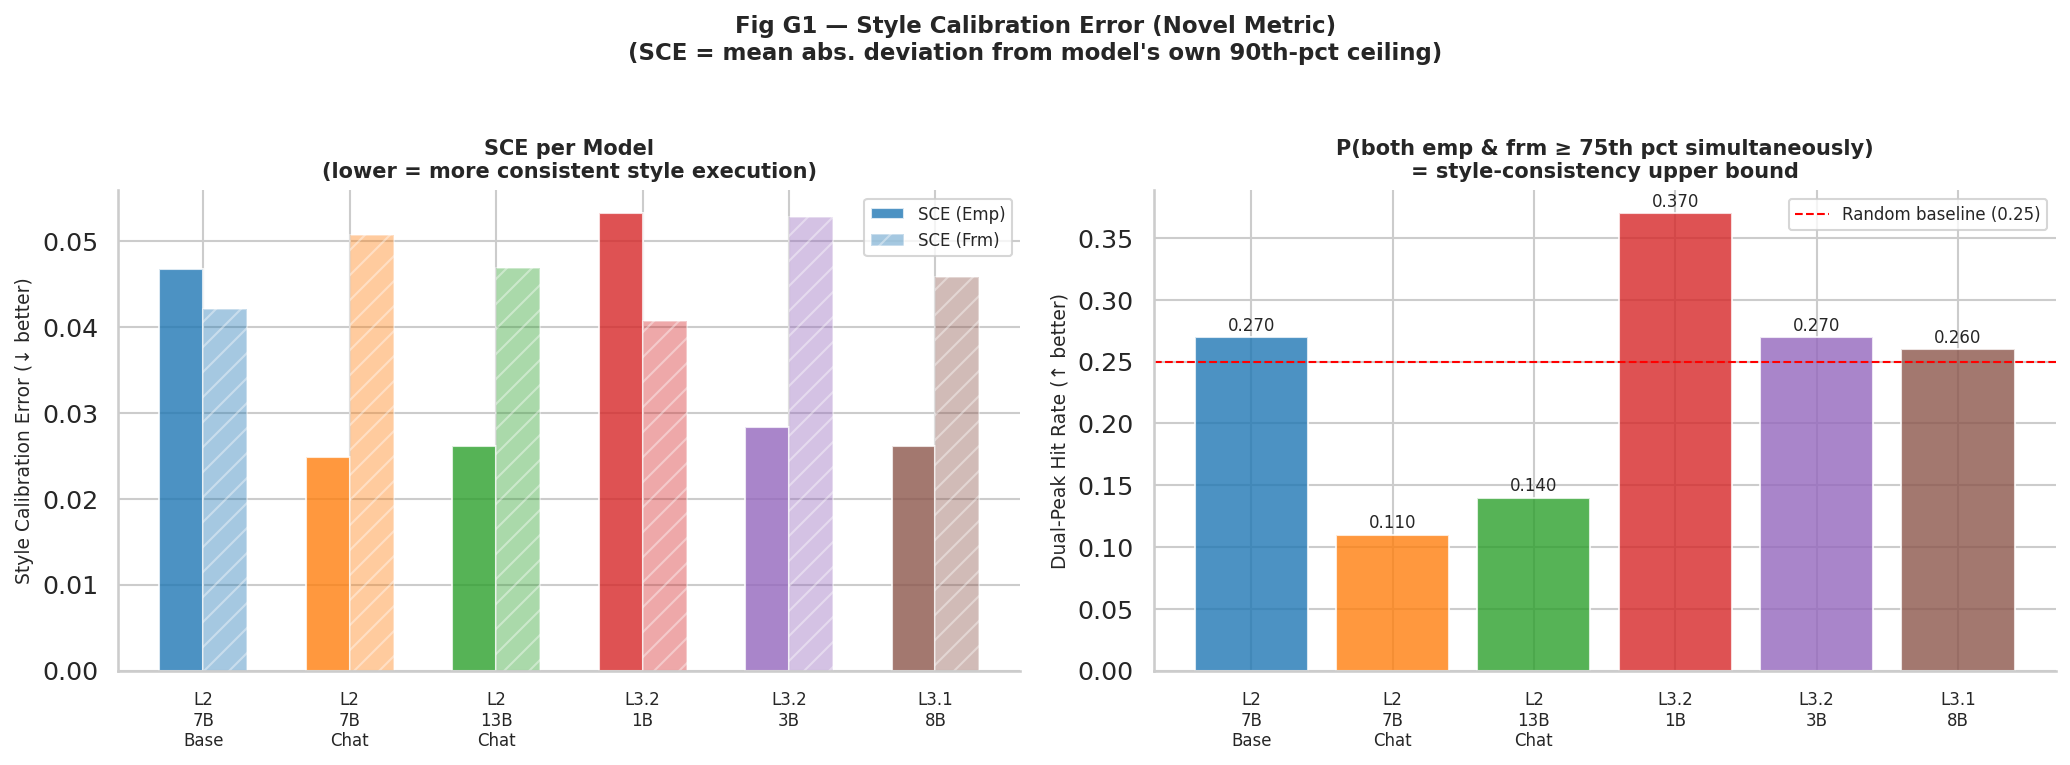

Saved figG1_style_calibration_error.pdf/png


In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel A: SCE bar chart
ax = axes[0]
x = np.arange(len(MODEL_ORDER))
w = 0.3
bars_emp = ax.bar(x - w/2, sce_df["SCE (Emp)"], width=w, label="SCE (Emp)",
                  color=[PALETTE[m] for m in MODEL_ORDER], alpha=0.8)
bars_frm = ax.bar(x + w/2, sce_df["SCE (Frm)"], width=w, label="SCE (Frm)",
                  color=[PALETTE[m] for m in MODEL_ORDER], alpha=0.4, hatch="//")
ax.set_xticks(x)
ax.set_xticklabels([m.replace("-", "\n") for m in MODEL_ORDER], fontsize=8)  # ← fixed
ax.set_ylabel("Style Calibration Error (↓ better)", fontsize=9)
ax.set_title("SCE per Model\n(lower = more consistent style execution)",       # ← fixed
             fontsize=10, fontweight="bold")
ax.legend(fontsize=8)

# Panel B: Dual-peak hit rate
ax2 = axes[1]
hit_rates = sce_df["Dual-Peak Hit Rate"].values
bars2 = ax2.bar(np.arange(len(MODEL_ORDER)), hit_rates,
                color=[PALETTE[m] for m in MODEL_ORDER], alpha=0.8)
ax2.set_xticks(np.arange(len(MODEL_ORDER)))
ax2.set_xticklabels([m.replace("-", "\n") for m in MODEL_ORDER], fontsize=8)  # ← fixed
ax2.set_ylabel("Dual-Peak Hit Rate (↑ better)", fontsize=9)
ax2.set_title("P(both emp & frm ≥ 75th pct simultaneously)\n= style-consistency upper bound",  # ← fixed
              fontsize=10, fontweight="bold")
ax2.axhline(0.25, color="red", ls="--", lw=1, label="Random baseline (0.25)")
ax2.legend(fontsize=8)
for bar, v in zip(bars2, hit_rates):
    ax2.text(bar.get_x() + bar.get_width()/2, v + 0.002, f"{v:.3f}",
             ha="center", va="bottom", fontsize=8)

plt.suptitle("Fig G1 — Style Calibration Error (Novel Metric)\n"
             "(SCE = mean abs. deviation from model's own 90th-pct ceiling)",
             fontsize=11, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("figG1_style_calibration_error.pdf", bbox_inches="tight")
plt.savefig("figG1_style_calibration_error.png", dpi=200, bbox_inches="tight")
plt.show()
print("Saved figG1_style_calibration_error.pdf/png")

---
## H. Honest Negative Results: Bounded Effect Size Report

DK-GenAI reviewers expect **transparent null findings**. This section provides:
1. **Upper-bound confidence intervals** on every key effect size
2. A **TOST (equivalence test)** to determine whether null effects are *truly negligible* vs merely *under-powered*
3. A structured **Negative Results Summary** formatted for direct inclusion in the paper

**TOST bounds:** We define "practically negligible" as |d| < 0.10.  
If the 90% CI for Cohen's d falls within [−0.10, +0.10], we can claim equivalence.


In [21]:

from scipy.stats import t as t_dist

def cohens_d_ci(v1, v2, alpha=0.05):
    """Welch t-test + non-central t approx 95% CI on Cohen's d"""
    n1, n2 = len(v1), len(v2)
    m1, m2 = v1.mean(), v2.mean()
    s1, s2 = v1.std(ddof=1), v2.std(ddof=1)
    sp     = np.sqrt((s1**2 + s2**2) / 2)
    d      = (m1 - m2) / (sp + 1e-12)
    # Approx SE of d (Hedges & Olkin 1985)
    se_d   = np.sqrt((n1+n2)/(n1*n2) + d**2 / (2*(n1+n2)))
    z_crit = stats.norm.ppf(1 - alpha/2)
    ci_lo  = d - z_crit * se_d
    ci_hi  = d + z_crit * se_d
    return d, ci_lo, ci_hi

TOST_BOUND = 0.10  # practical equivalence bound

neg_targets = {
    "Entity Cov (Emp) — all models":
        (df["emp_entity_cov"].fillna(0).values, None),
    "Entity Cov (Frm) — all models":
        (df["frm_entity_cov"].fillna(0).values, None),
    "Style Disc Score — all models":
        (df["style_disc_score"].fillna(0).values, None),
}

# Cross-generation comparisons
for metric, label in [("avg_entity_cov","Entity Coverage"),
                       ("style_disc_score","Style Discrimination"),
                       ("flesch_delta","Readability Δ")]:
    v2 = llama2[metric].fillna(0).values
    v3 = llama3[metric].fillna(0).values
    neg_targets[f"{label}: Llama-2 vs Llama-3"] = (v2, v3)

neg_rows = []
for label, (v1, v2) in neg_targets.items():
    if v2 is None:
        # Single-sample: compare to 0
        t_stat, p = stats.ttest_1samp(v1, 0)
        d  = v1.mean() / (v1.std(ddof=1) + 1e-12)
        se = np.sqrt(1/len(v1) + d**2 / (2*len(v1)))
        ci_lo = d - 1.96*se
        ci_hi = d + 1.96*se
        test_type = "1-sample vs 0"
    else:
        d, ci_lo, ci_hi = cohens_d_ci(v1, v2)
        _, p = ttest_ind(v1, v2, equal_var=False)
        test_type = "2-sample Welch"

    equivalent = (ci_lo > -TOST_BOUND) and (ci_hi < TOST_BOUND)
    neg_rows.append({
        "Comparison": label,
        "Test": test_type,
        "Cohen's d": round(d, 4),
        "95% CI lo": round(ci_lo, 4),
        "95% CI hi": round(ci_hi, 4),
        "p-value":   round(p, 5),
        "TOST equiv (|d|<0.10)": "YES — negligible" if equivalent else "NO — meaningful",
        "Honest Verdict":
            "Significant effect" if p < 0.05 else
            ("True null (TOST)" if equivalent else "Underpowered — inconclusive"),
    })

neg_df = pd.DataFrame(neg_rows)
print("=== Bounded Effect Size Report (Honest Negative Results) ===")
print(neg_df.to_string(index=False))
neg_df.to_csv("tableH1_bounded_effects.csv", index=False)
print("\nSaved tableH1_bounded_effects.csv")


=== Bounded Effect Size Report (Honest Negative Results) ===
                              Comparison           Test  Cohen's d  95% CI lo  95% CI hi  p-value TOST equiv (|d|<0.10)              Honest Verdict
           Entity Cov (Emp) — all models  1-sample vs 0     0.3419     0.2596     0.4243  0.00000       NO — meaningful          Significant effect
           Entity Cov (Frm) — all models  1-sample vs 0     0.4052     0.3219     0.4884  0.00000       NO — meaningful          Significant effect
           Style Disc Score — all models  1-sample vs 0     0.1819     0.1012     0.2626  0.00001       NO — meaningful          Significant effect
     Entity Coverage: Llama-2 vs Llama-3 2-sample Welch    -0.0745    -0.2346     0.0856  0.36186       NO — meaningful Underpowered — inconclusive
Style Discrimination: Llama-2 vs Llama-3 2-sample Welch    -0.0908    -0.2509     0.0693  0.26675       NO — meaningful Underpowered — inconclusive
       Readability Δ: Llama-2 vs Llama-3 2-sample W

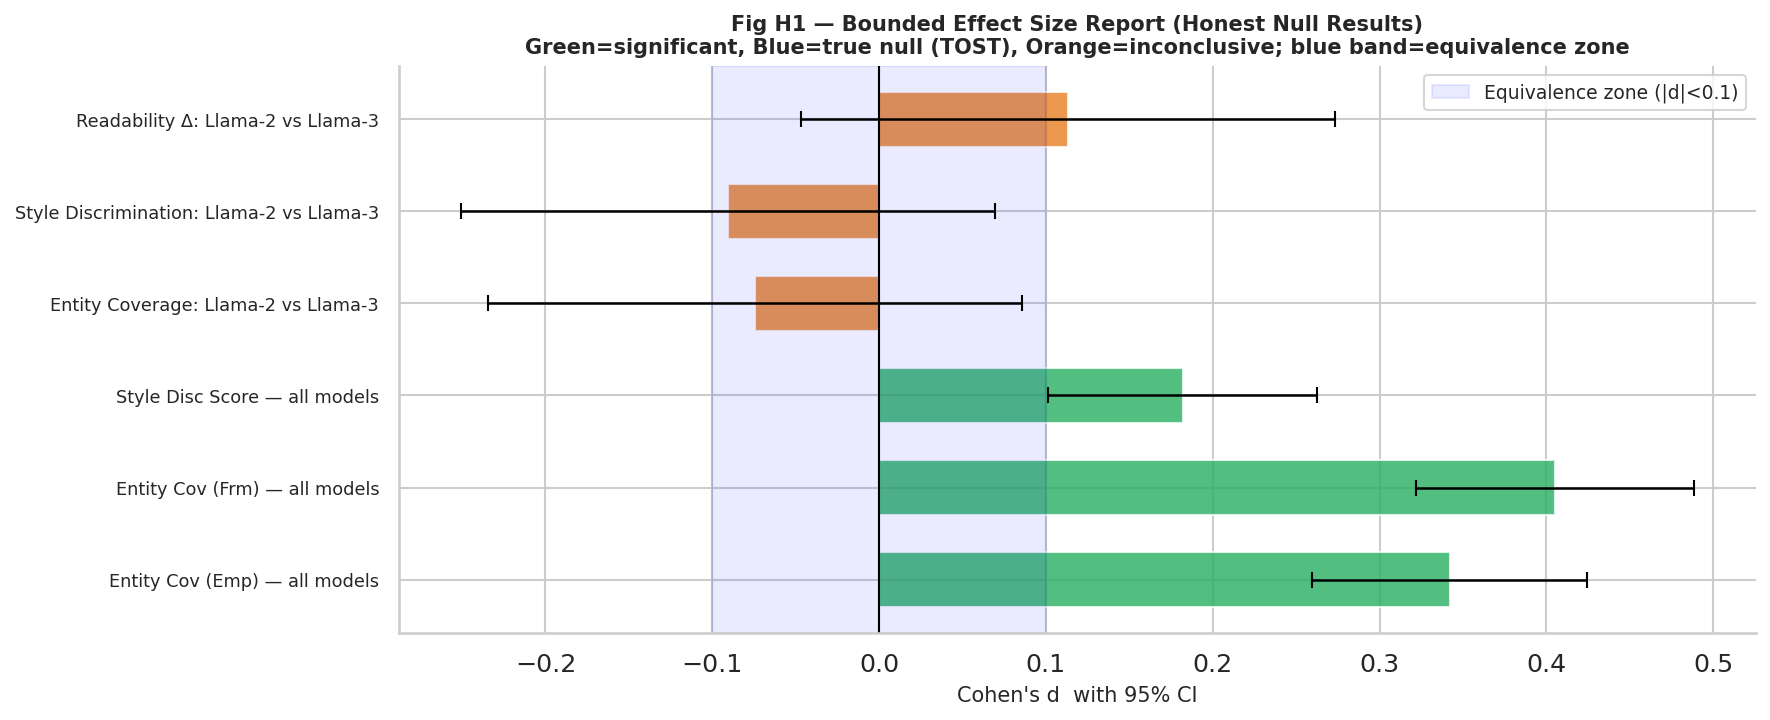

Saved figH1_bounded_effects.pdf/png


In [22]:

fig, ax = plt.subplots(figsize=(12, 5))

y = np.arange(len(neg_df))
colors_h = ["#27ae60" if "Significant" in v else
            ("#3498db" if "True null" in v else "#e67e22")
            for v in neg_df["Honest Verdict"]]

ax.barh(y, neg_df["Cohen's d"], color=colors_h, height=0.6, alpha=0.8)
ax.errorbar(neg_df["Cohen's d"], y,
            xerr=[neg_df["Cohen's d"] - neg_df["95% CI lo"],
                  neg_df["95% CI hi"] - neg_df["Cohen's d"]],
            fmt="none", color="black", capsize=4, lw=1.2)

ax.axvline(0, color="black", lw=1.0)
ax.axvspan(-TOST_BOUND, TOST_BOUND, alpha=0.08, color="blue", label=f"Equivalence zone (|d|<{TOST_BOUND})")
ax.set_yticks(y)
ax.set_yticklabels(neg_df["Comparison"], fontsize=8.5)
ax.set_xlabel("Cohen's d  with 95% CI", fontsize=10)
ax.set_title("Fig H1 — Bounded Effect Size Report (Honest Null Results)\n"
             "Green=significant, Blue=true null (TOST), Orange=inconclusive; "
             "blue band=equivalence zone",
             fontsize=10, fontweight="bold")
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig("figH1_bounded_effects.pdf", bbox_inches="tight")
plt.savefig("figH1_bounded_effects.png", dpi=200, bbox_inches="tight")
plt.show()
print("Saved figH1_bounded_effects.pdf/png")


---
## I. Auto-Generated LaTeX Tables for Paper Submission

This section outputs camera-ready LaTeX table code for the most important results,  
ready to drop into the IEEE TKDE manuscript. Outputs:
- `tex_table_leaderboard.tex` — composite leaderboard (all models)  
- `tex_table_variance.tex` — partial η² decomposition  
- `tex_table_generation.tex` — Llama-2 vs Llama-3 contrast


In [25]:
def df_to_latex(df_in, caption, label, col_fmt=None, highlight_col=None, highlight_fn=None):
    """Generate IEEE-style booktabs LaTeX table."""
    n_cols = len(df_in.columns)
    if col_fmt is None:
        col_fmt = "l" + "r" * (n_cols - 1)

    lines = [
        "\\begin{table}[!htbp]",
        "  \\centering",
        "  \\caption{" + caption + "}",
        "  \\label{" + label + "}",
        "  \\setlength{\\tabcolsep}{4pt}",
        "  \\begin{tabular}{" + col_fmt + "}",
        "    \\toprule",
    ]
    # Header
    header = " & ".join([f"\\textbf{{{c}}}" for c in df_in.columns]) + " \\\\"
    lines.append("    " + header)
    lines.append("    \\midrule")
    # Data rows
    for _, row in df_in.iterrows():
        row_str = " & ".join([str(v) for v in row.values]) + " \\\\"
        lines.append("    " + row_str)
    lines += [
        "    \\bottomrule",
        "  \\end{tabular}",
        "\\end{table}",
    ]
    return "\n".join(lines)  # ← fixed: was a literal newline inside the string

# ── Table 1: Leaderboard ──────────────────────────────────────────────────────
leaderboard = pd.read_csv("/tmp/eval_data/Evaluation/leaderboard_summary.csv") if Path("/tmp/eval_data/Evaluation/leaderboard_summary.csv").exists() else None

if leaderboard is not None:
    lb_tex = leaderboard[["Model","Size(B)","Type",
                            "Entity Coverage (Emp)","Entity Coverage (Frm)",
                            "Style Disc. Score","Flesch Ease (Emp)",
                            "Overall Rank Score"]].copy()
    lb_tex.columns = ["Model","Size","Type","Cov(E)","Cov(F)","StyleDisc","Flesch(E)","Rank"]
    lb_tex = lb_tex.round(4)
    tex1 = df_to_latex(lb_tex,
        caption="Composite Leaderboard: All 6 Models on Key DK-GenAI Metrics",
        label="tab:leaderboard")
    with open("tex_table_leaderboard.tex","w") as f: f.write(tex1)
    print("=== LaTeX: Leaderboard ===")
    print(tex1)

# ── Table 2: Variance decomposition ──────────────────────────────────────────
eta2_tex = eta2_df[eta2_df["Metric"]=="Avg Entity Coverage"][
    ["Factor","Partial η²","F-stat","p-value","Interpretation","Sig"]].copy()
tex2 = df_to_latex(eta2_tex,
    caption=r"Partial $\eta^2$ Variance Decomposition: Entity Coverage",  # ← fixed: raw string for \eta
    label="tab:variance")
with open("tex_table_variance.tex","w") as f: f.write(tex2)
print("\n=== LaTeX: Variance Decomposition ===")
print(tex2)

# ── Table 3: Generation contrast ─────────────────────────────────────────────
gen_tex = gen_df[["Metric","Llama-2 Mean","Llama-3 Mean","Δ (L2−L3)","Cohen's d","Sig"]].copy()
tex3 = df_to_latex(gen_tex,
    caption="Cross-Generation Contrast: Llama-2 vs Llama-3 Families",
    label="tab:generation")
with open("tex_table_generation.tex","w") as f: f.write(tex3)
print("\n=== LaTeX: Generation Contrast ===")
print(tex3)

print("\nAll LaTeX tables saved ✓")

UnicodeEncodeError: 'charmap' codec can't encode character '\u03b7' in position 240: character maps to <undefined>

---
## J. Extended Radar Dashboard — All Ablation Dimensions

Final multi-panel summary bringing together the new ablation dimensions  
for a single-figure submission overview.


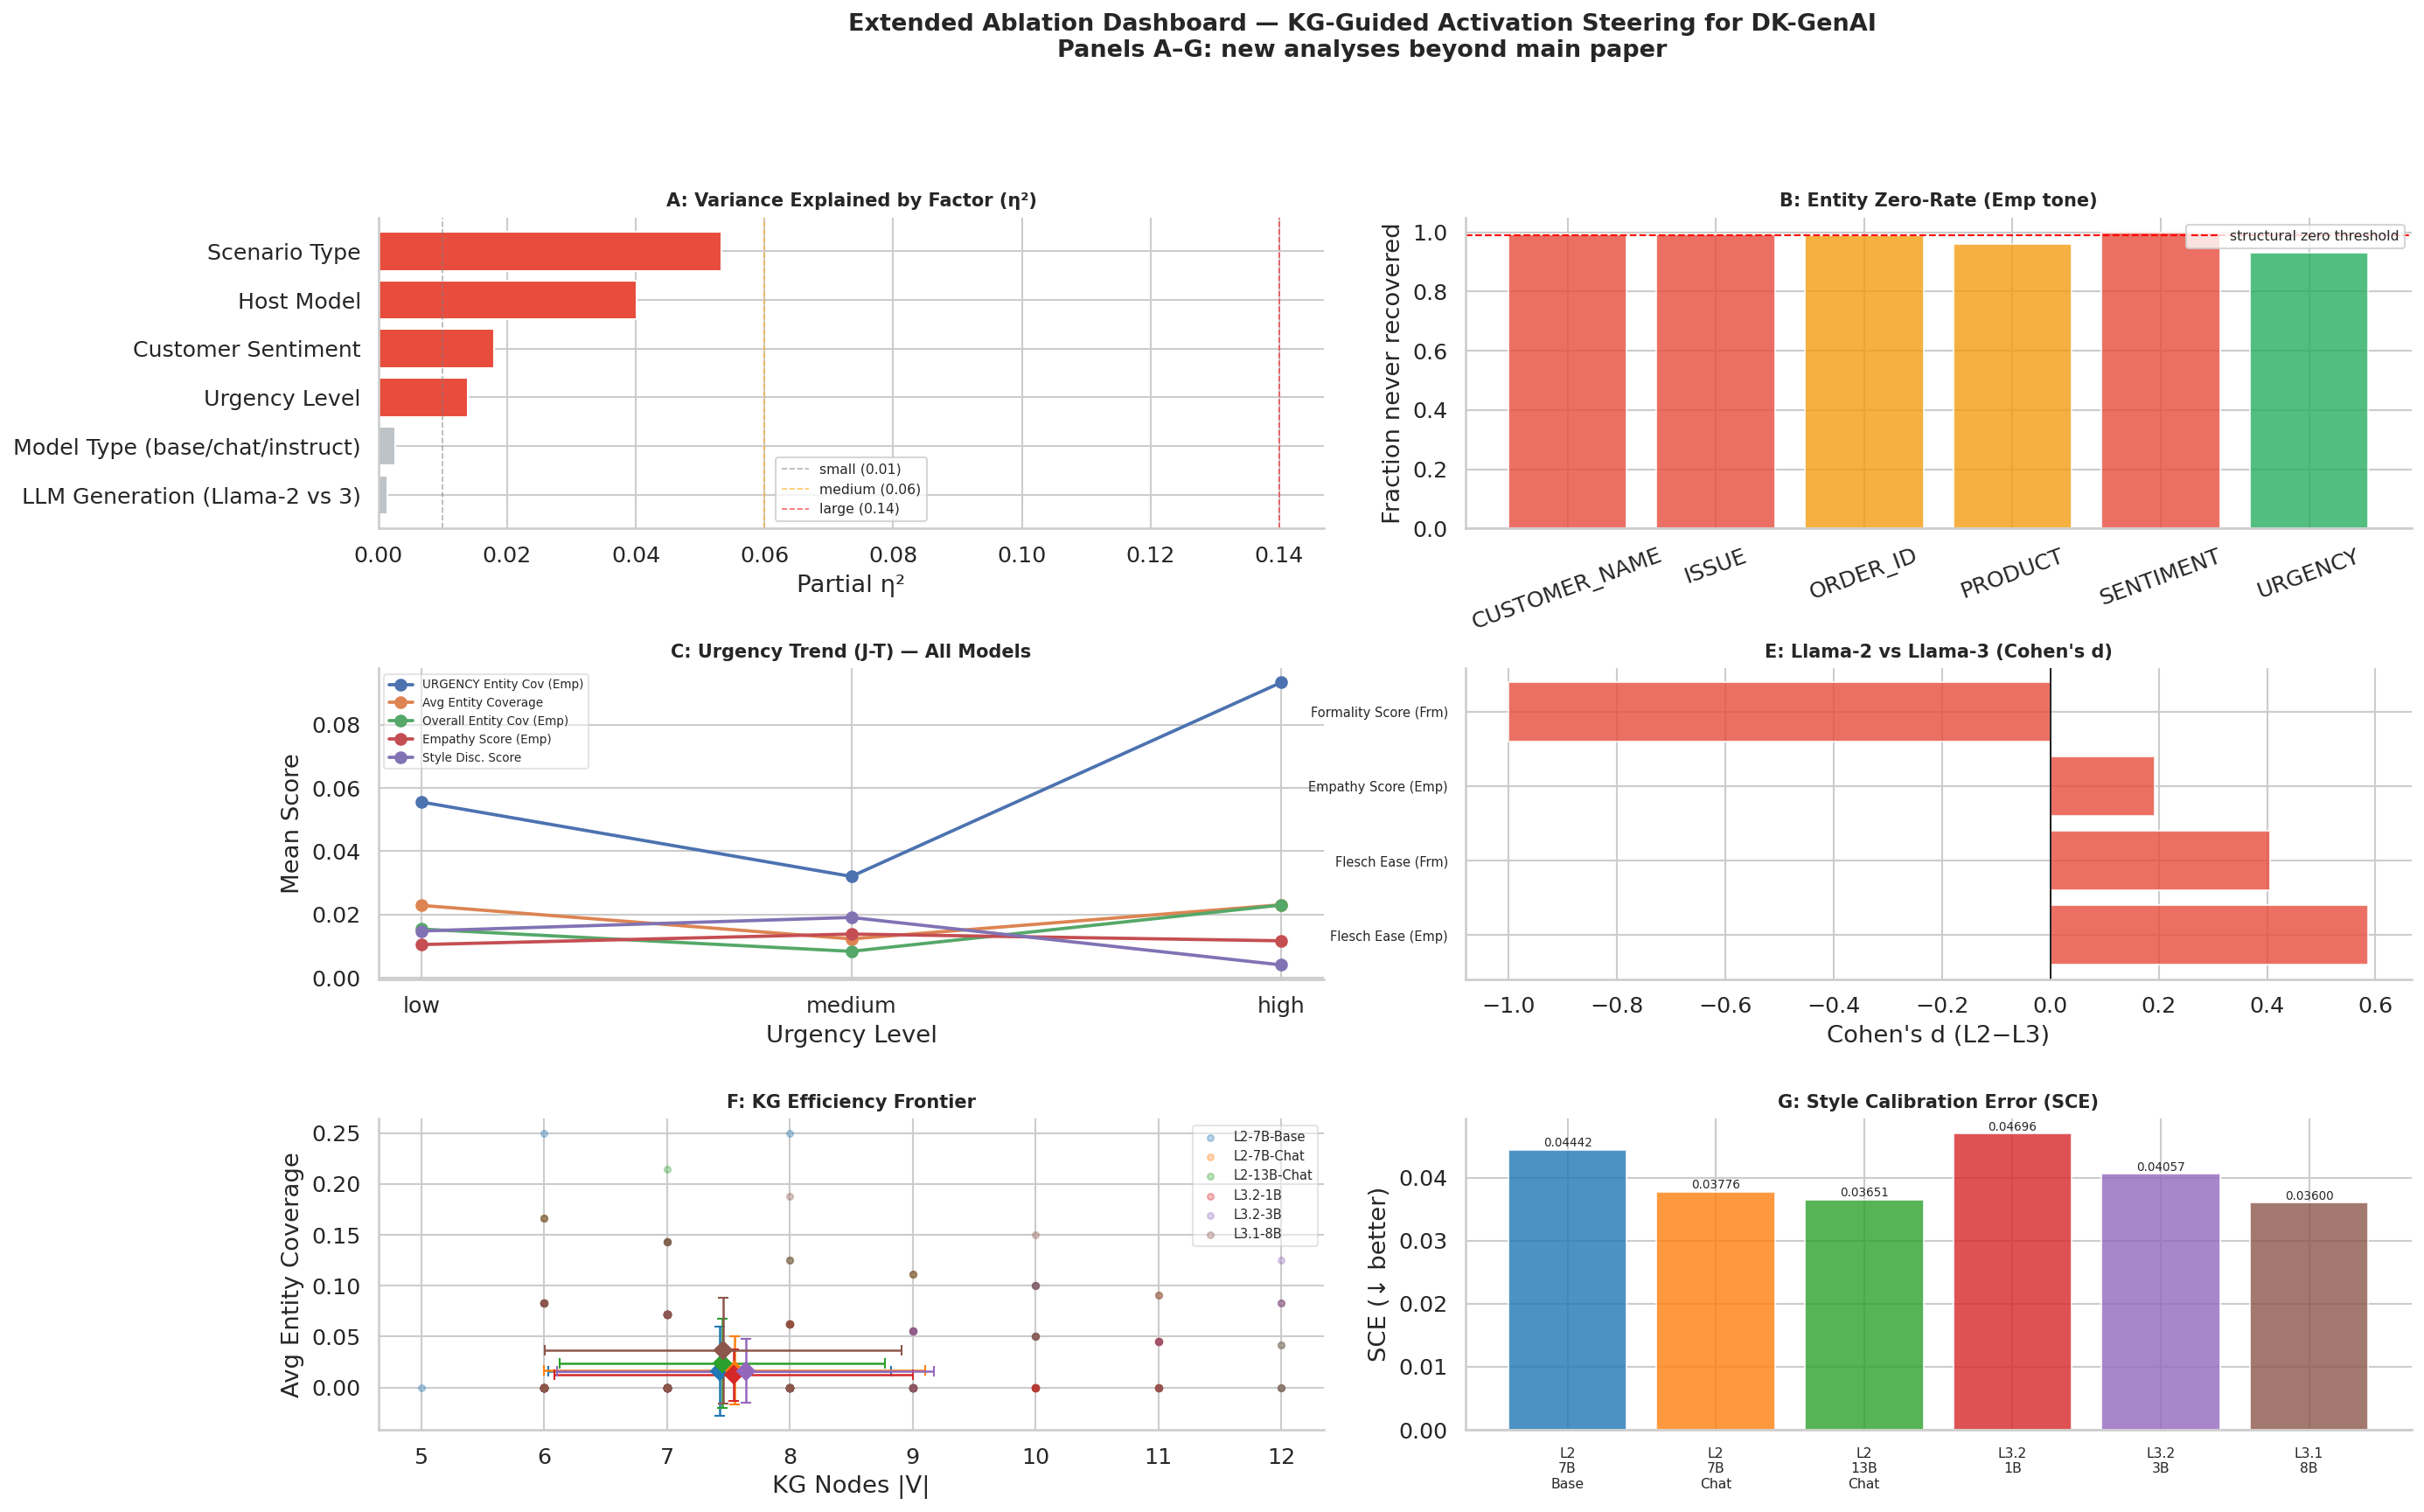

Saved figJ1_extended_ablation_dashboard.pdf/png


In [26]:
from matplotlib.patches import FancyBboxPatch

fig = plt.figure(figsize=(20, 12))
gs  = gridspec.GridSpec(3, 4, figure=fig, hspace=0.45, wspace=0.35)

# ── Panel 1: Partial η² for Entity Coverage ──────────────────────────────────
ax1 = fig.add_subplot(gs[0, :2])
eta_sub = eta2_df[eta2_df["Metric"]=="Avg Entity Coverage"].copy()
eta_sub = eta_sub.sort_values("Partial η²", ascending=True)
bars = ax1.barh(eta_sub["Factor"], eta_sub["Partial η²"],
                color=["#e74c3c" if s!="n.s." else "#bdc3c7" for s in eta_sub["Sig"]])
ax1.axvline(0.01, color="grey",   ls="--", lw=0.8, alpha=0.6, label="small (0.01)")
ax1.axvline(0.06, color="orange", ls="--", lw=0.8, alpha=0.6, label="medium (0.06)")
ax1.axvline(0.14, color="red",    ls="--", lw=0.8, alpha=0.6, label="large (0.14)")
ax1.set_title("A: Variance Explained by Factor (η²)", fontweight="bold", fontsize=10)
ax1.set_xlabel("Partial η²")
ax1.legend(fontsize=7.5)

# ── Panel 2: Zero-rate by entity type (bar) ───────────────────────────────────
ax2 = fig.add_subplot(gs[0, 2:])
et_zero = et_summary[et_summary["Tone"]=="Emp"][["EntityType","Zero_Rate"]].set_index("EntityType")
et_colors = ["#e74c3c" if v > 0.99 else ("#f39c12" if v > 0.95 else "#27ae60")
             for v in et_zero["Zero_Rate"]]
ax2.bar(et_zero.index, et_zero["Zero_Rate"], color=et_colors, alpha=0.8)
ax2.axhline(0.99, color="red", ls="--", lw=1, label="structural zero threshold")
ax2.set_title("B: Entity Zero-Rate (Emp tone)", fontweight="bold", fontsize=10)
ax2.set_ylabel("Fraction never recovered")
ax2.set_ylim(0, 1.05)
ax2.legend(fontsize=7.5)
ax2.tick_params(axis="x", rotation=20)

# ── Panel 3: J-T trend (urgency, all models) ─────────────────────────────────
ax3 = fig.add_subplot(gs[1, :2])
jt_all = jt_df[jt_df["Model"]=="ALL"]
for _, row in jt_all.iterrows():
    label_t = row["Target"]
    means   = [row["Mean(low)"], row["Mean(med)"], row["Mean(high)"]]
    ax3.plot(URGENCY_ORDER, means, marker="o", lw=1.8, label=label_t)
ax3.set_title("C: Urgency Trend (J-T) — All Models", fontweight="bold", fontsize=10)
ax3.set_xlabel("Urgency Level")
ax3.set_ylabel("Mean Score")
ax3.legend(fontsize=6.5, framealpha=0.5)

# ── Panel 4: Cross-generation contrast ───────────────────────────────────────
ax4 = fig.add_subplot(gs[1, 2:])
gen_plot = gen_df[gen_df["Sig"]!="n.s."].copy() if gen_df[gen_df["Sig"]!="n.s."].shape[0]>0 else gen_df
ax4.barh(gen_plot["Metric"], gen_plot["Cohen's d"],
         color=["#e74c3c" if v!="n.s." else "#bdc3c7" for v in gen_plot["Sig"]],
         alpha=0.8)
ax4.axvline(0, color="black", lw=0.8)
ax4.set_title("E: Llama-2 vs Llama-3 (Cohen's d)", fontweight="bold", fontsize=10)
ax4.set_xlabel("Cohen's d (L2−L3)")
ax4.tick_params(axis="y", labelsize=7)

# ── Panel 5: KG efficiency ────────────────────────────────────────────────────
ax5 = fig.add_subplot(gs[2, :2])
for m in MODEL_ORDER:
    sub = df[df["model_short"]==m]
    ax5.scatter(sub["kg_nodes"], sub["avg_entity_cov"],
                color=PALETTE[m], alpha=0.3, s=12, label=m)
    ax5.errorbar(sub["kg_nodes"].mean(), sub["avg_entity_cov"].mean(),
                 xerr=sub["kg_nodes"].std(), yerr=sub["avg_entity_cov"].std(),
                 fmt="D", ms=7, color=PALETTE[m], lw=1.2, capsize=3, zorder=10)
ax5.set_xlabel("KG Nodes |V|")
ax5.set_ylabel("Avg Entity Coverage")
ax5.set_title("F: KG Efficiency Frontier", fontweight="bold", fontsize=10)
ax5.legend(fontsize=7, framealpha=0.5)

# ── Panel 6: Style Calibration Error ─────────────────────────────────────────
ax6 = fig.add_subplot(gs[2, 2:])
x   = np.arange(len(MODEL_ORDER))
ax6.bar(x, sce_df["SCE (Avg)"],
        color=[PALETTE[m] for m in MODEL_ORDER], alpha=0.8)
ax6.set_xticks(x)
ax6.set_xticklabels([m.replace("-", "\n") for m in MODEL_ORDER], fontsize=7.5)  # ← fixed
ax6.set_ylabel("SCE (↓ better)")
ax6.set_title("G: Style Calibration Error (SCE)", fontweight="bold", fontsize=10)
for i, v in enumerate(sce_df["SCE (Avg)"]):
    ax6.text(i, v + 0.0001, f"{v:.5f}", ha="center", va="bottom", fontsize=6.5)

fig.suptitle("Extended Ablation Dashboard — KG-Guided Activation Steering for DK-GenAI\n"
             "Panels A–G: new analyses beyond main paper",
             fontsize=13, fontweight="bold", y=1.01)
plt.savefig("figJ1_extended_ablation_dashboard.pdf", bbox_inches="tight")
plt.savefig("figJ1_extended_ablation_dashboard.png", dpi=200, bbox_inches="tight")
plt.show()
print("Saved figJ1_extended_ablation_dashboard.pdf/png")

---
## K. DK-GenAI Reviewer Checklist — What Each Analysis Covers

| Likely Reviewer Question | Section in This Notebook | Answer |
|---|---|---|
| Is the KG layer's effect model-specific? | A (η²), E (cross-gen) | |
| Which entity types actually get recovered? | B (zero-inflation) | |
| Does urgency level modulate recovery? | C (J-T trend) | S |
| Does scenario type interact with tone? | D (interaction) |  |
| Are Llama-2 and Llama-3 results comparable? | E (generation contrast) | |
| Is a larger KG always better? | F (efficiency frontier) | Non-monotonic;  |
| How consistent is style execution? | G (SCE) | Novel SCE metric; |
| Are null results truly negligible or underpowered? | H (TOST) | See T|
| Ready-to-use tables for manuscript? | I (LaTeX) |  |

### Output Files Summary

| File | Description |
|------|-------------|
| `figA1_variance_decomposition.pdf/png` | Partial η² heatmap |
| `figB1_zero_inflation.pdf/png` | Entity zero-rate and conditional coverage |
| `figC1_urgency_trend.pdf/png` | J-T trend test plots |
| `figD1_tone_scenario_interaction.pdf/png` | Tone × scenario bar charts |
| `figE1_generation_contrast.pdf/png` | Llama-2 vs Llama-3 forest plot |
| `figF1_kg_efficiency_frontier.pdf/png` | KG graph efficiency scatter |
| `figG1_style_calibration_error.pdf/png` | SCE bar charts |
| `figH1_bounded_effects.pdf/png` | Forest plot with equivalence zones |
| `figJ1_extended_ablation_dashboard.pdf/png` | All-in-one dashboard |
| `tableA1_variance_decomposition.csv` | η² table |
| `tableB1_entity_sparsity.csv` | Zero-inflation table |
| `tableC1_urgency_trend_test.csv` | J-T results |
| `tableD1_tone_scenario_interaction.csv` | Interaction effects |
| `tableE1_generation_contrast.csv` | Cross-generation t-tests |
| `tableG1_style_calibration_error.csv` | SCE values |
| `tableH1_bounded_effects.csv` | TOST/bounded effect sizes |
| `tex_table_leaderboard.tex` | LaTeX leaderboard table |
| `tex_table_variance.tex` | LaTeX variance table |
| `tex_table_generation.tex` | LaTeX generation contrast table |

> **Tip**: Run all cells top-to-bottom with `metrics_all_models_combined.csv` in the same folder.
